<a href="https://colab.research.google.com/github/hilalariboga34/ICT-COMPETITION-2027/blob/main/FaceForensics%2B%2B_C23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Faz 1: Ortam Kurulumu, Dosya Yapılandırması ve Kütüphaneler

In [ ]:
# ==========================================
# FAZ 1: KÜTÜPHANE KURULUMLARI, ORTAM VE DOSYA YAPISI
# ==========================================
!pip install -q ultralytics timm==0.9.12 decord==0.6.0 albumentations==1.3.1

import os
import sys
import glob
import shutil
import random
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from decord import VideoReader, cpu
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')

# 1. Drive Bağlantısı ve Dizin Kontrolü
if 'google.colab' in sys.modules:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/FaceForensics++'
else:
    PROJECT_ROOT = os.path.join(os.getcwd(), 'FaceForensics++')

# 2. Klasör Yapısı
folders = [
    'data/raw/FaceForensics++_C23',
    'data/processed',
    'notebooks',
    'src/data',
    'src/models',
    'src/utils',
    'weights'
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    if not os.path.exists(path):
        os.makedirs(path)

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 3. Sistem Kontrolü
print("Sistem ve Kütüphane Kontrolü:")
print(f"PyTorch Sürümü: {torch.__version__}")
if torch.cuda.is_available():
    print(f"Kullanılan GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print("Apple Silicon (MPS) donanım hızlandırması aktif.")
else:
    print("GPU/MPS bulunamadı, CPU kullanılacak.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 8.1 MB/s eta 0:00:00
Mounted at /content/drive
Sistem ve Kütüphane Kontrolü:
PyTorch Sürümü: 2.11.0+cu128
Kullanılan GPU: NVIDIA L4


# Faz 2: Veri Keşfi, İstatistiksel Analiz ve Görselleştirme

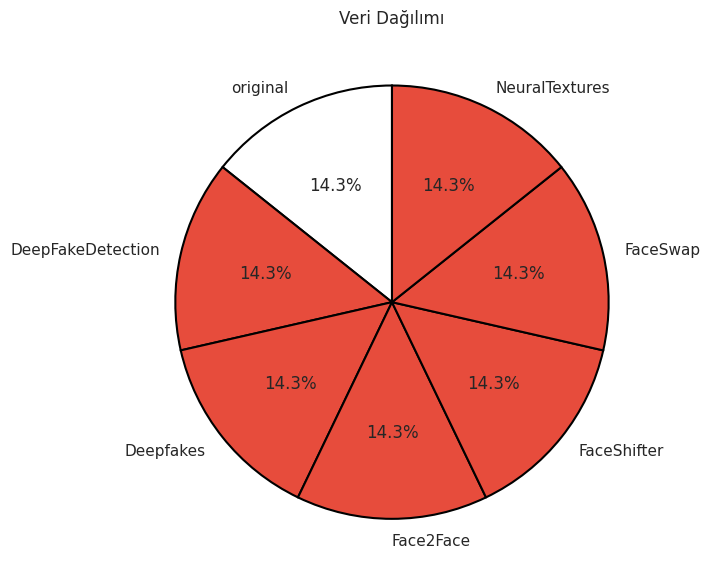

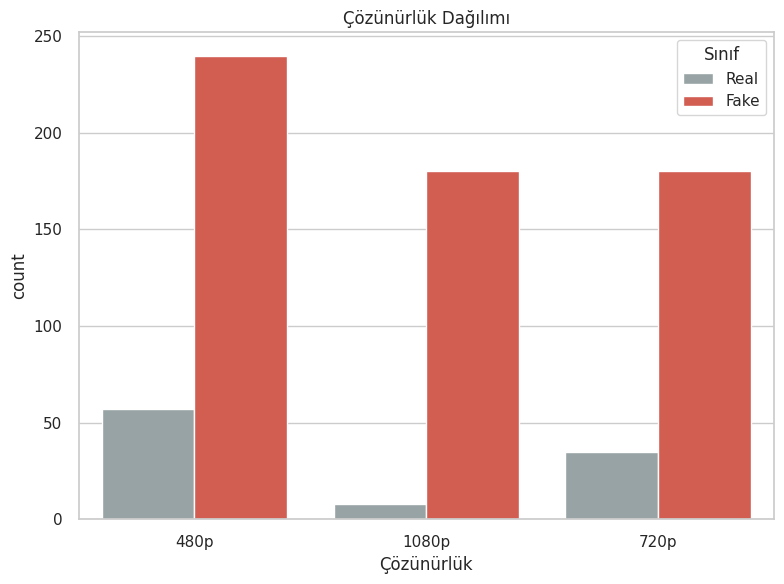

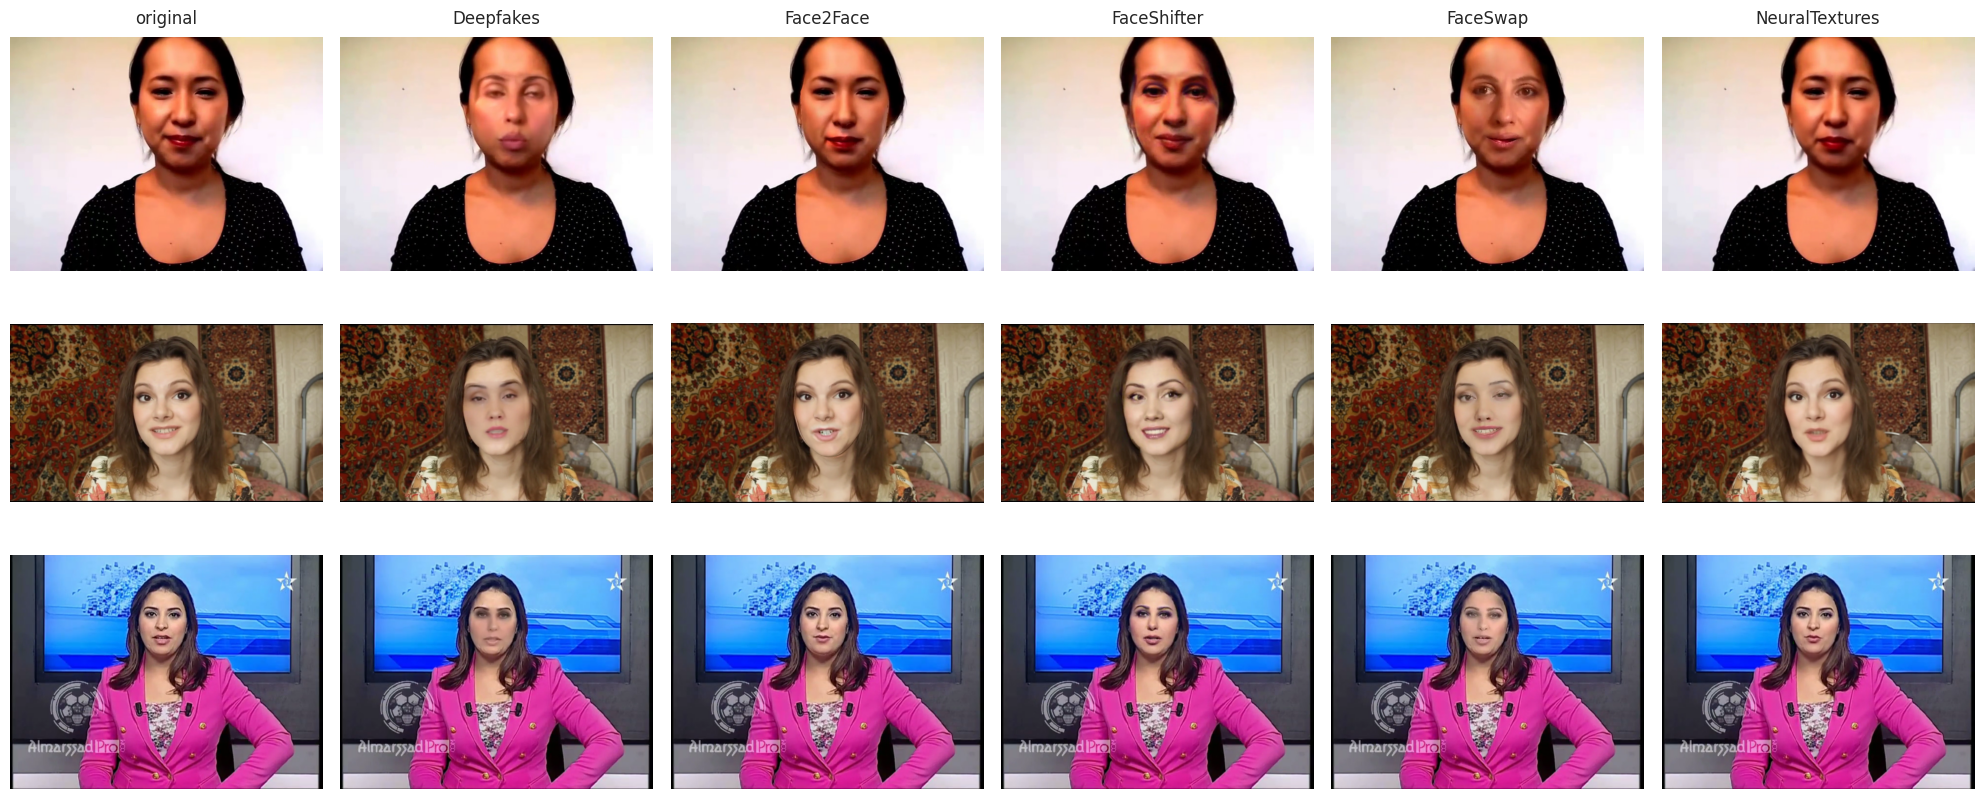

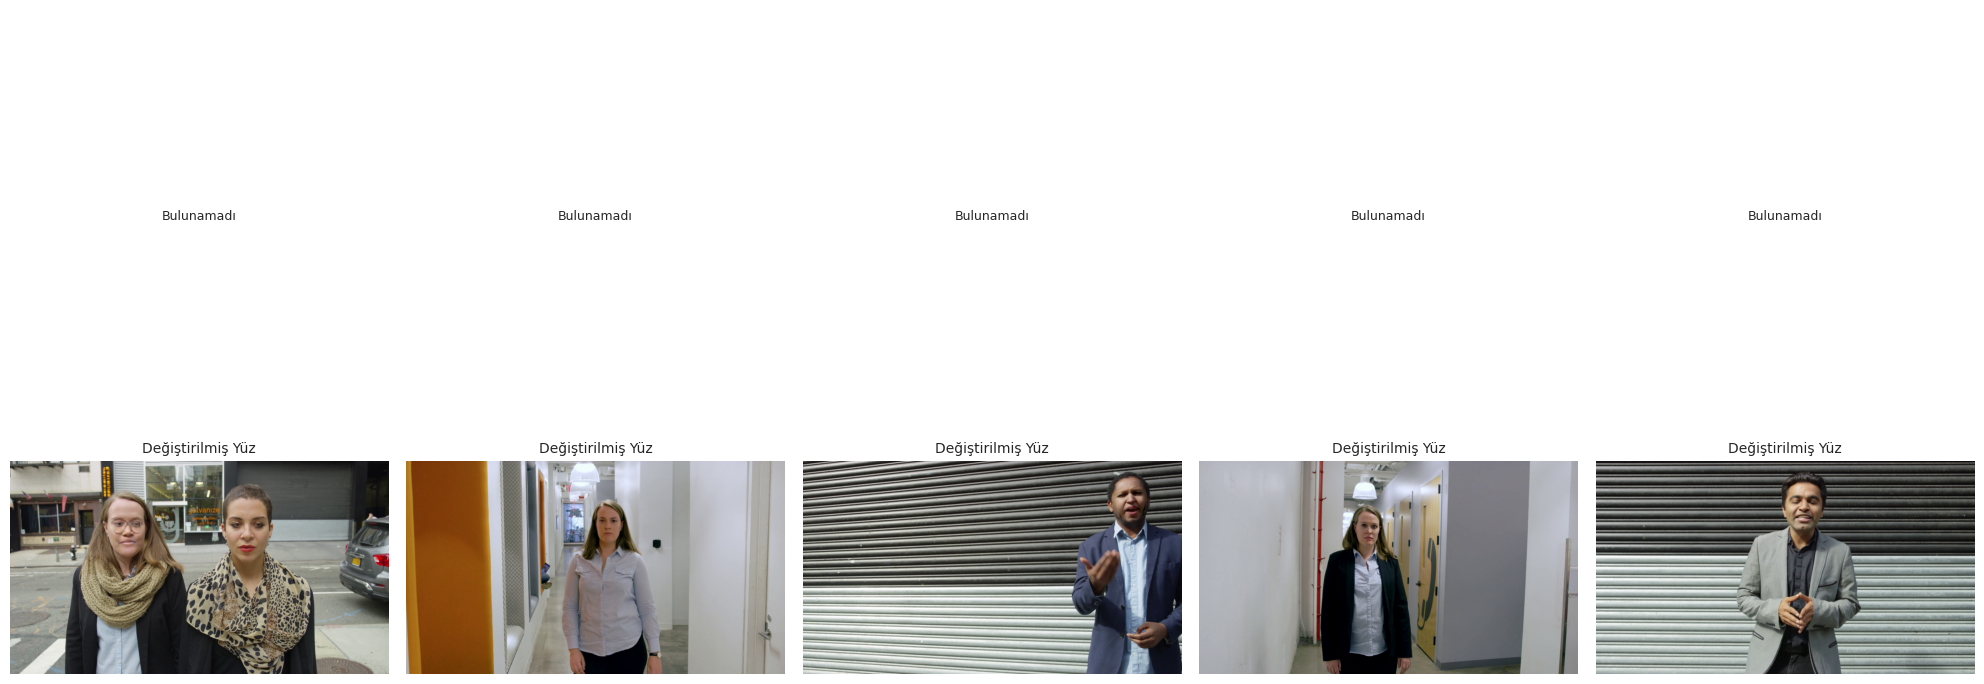

In [ ]:
# ==========================================
# FAZ 2: VERİ TAŞIMA, İSTATİSTİK VE GÖRSELLEŞTİRME
# ==========================================

# Grafik ayarları
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'figure.autolayout': True, 'font.size': 12})

# 1. VERİYİ TAŞIMA (Güvenli Kontrol)
DRIVE_BASE_PATH = '/content/drive/MyDrive/FaceForensics++/data/raw'
COLAB_LOCAL_PATH = '/content/FaceForensics_Data'

drive_folders = glob.glob(os.path.join(DRIVE_BASE_PATH, 'FaceForensics++_C23*'))
if not drive_folders:
    print("Veri bulunamadı. Lütfen yolu kontrol et.")
else:
    drive_data_dir = drive_folders[0]
    check_path = os.path.join(COLAB_LOCAL_PATH, 'original')

    if not os.path.exists(check_path):
        if os.path.exists(COLAB_LOCAL_PATH):
            shutil.rmtree(COLAB_LOCAL_PATH)
        shutil.copytree(drive_data_dir, COLAB_LOCAL_PATH)
    else:
        pass # Veri zaten Colab diskindeyse atla

# 2. İSTATİSTİK GRAFİKLERİ
methods = ['original', 'DeepFakeDetection', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
metadata_list = []
MAX_SAMPLE = 100

for method in methods:
    folder_path = os.path.join(COLAB_LOCAL_PATH, method)
    video_files = glob.glob(os.path.join(folder_path, '*.mp4'))[:MAX_SAMPLE]
    label = 'Real' if method == 'original' else 'Fake'

    for vid_path in video_files:
        try:
            vr = VideoReader(vid_path, ctx=cpu(0))
            frame_count = len(vr)
            fps = vr.get_avg_fps()
            h, w, _ = vr[0].shape

            res = "1080p" if h >= 1080 else ("720p" if h >= 720 else "480p")
            metadata_list.append({
                'Yöntem': method, 'Sınıf': label, 'Çözünürlük': res,
                'FPS': round(fps), 'Süre': frame_count / (fps if fps>0 else 30)
            })
        except: continue

df_meta = pd.DataFrame(metadata_list)

if not df_meta.empty:
    # Dağılım Grafiği (Orijinal beyaz, diğerleri kırmızı)
    plt.figure(figsize=(8, 6))
    method_counts = df_meta['Yöntem'].value_counts()
    colors = ['#ffffff' if m == 'original' else '#e74c3c' for m in method_counts.index]

    plt.pie(method_counts, labels=method_counts.index, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
    plt.title('Veri Dağılımı')
    plt.savefig('grafik_dagilim.svg', format='svg')
    plt.show()

    # Çözünürlük Grafiği
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_meta, x='Çözünürlük', hue='Sınıf', palette=['#95a5a6', '#e74c3c'])
    plt.title('Çözünürlük Dağılımı')
    plt.savefig('grafik_cozunurluk.svg', format='svg')
    plt.show()

# 3. YÜZ EŞLEŞTİRME MATRİSİ (3 Kullanıcı x 6 Yöntem)
methods_3x6 = ['original', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
original_videos = glob.glob(os.path.join(COLAB_LOCAL_PATH, 'original', '*.mp4'))

if len(original_videos) >= 3:
    selected_users = random.sample(original_videos, 3)
    fig1, axes1 = plt.subplots(3, 6, figsize=(20, 10))

    for row_idx, base_vid in enumerate(selected_users):
        vid_name = os.path.basename(base_vid)
        base_id = vid_name.split('.')[0]

        for col_idx, method in enumerate(methods_3x6):
            ax = axes1[row_idx, col_idx]

            if method == 'original':
                target_vid = base_vid
            else:
                pattern = os.path.join(COLAB_LOCAL_PATH, method, f"{base_id}_*.mp4")
                matches = glob.glob(pattern)
                target_vid = matches[0] if matches else None

            if target_vid and os.path.exists(target_vid):
                try:
                    vr = VideoReader(target_vid, ctx=cpu(0))
                    ax.imshow(vr[50].asnumpy())
                    if row_idx == 0: ax.set_title(method, pad=10)
                except: ax.set_title("Hata")
            else:
                ax.set_facecolor('lightgray')
                ax.text(0.5, 0.5, 'Bulunamadı', ha='center', va='center')
                if row_idx == 0: ax.set_title(method, pad=10)
            ax.axis('off')

    plt.savefig('matris_3x6.svg', format='svg')
    plt.show()

# 4. DEEPFAKEDETECTION MATRİSİ (5 Örnek)
dfd_videos = glob.glob(os.path.join(COLAB_LOCAL_PATH, 'DeepFakeDetection', '*.mp4'))

if len(dfd_videos) >= 5:
    selected_dfd = random.sample(dfd_videos, 5)
    fig2, axes2 = plt.subplots(2, 5, figsize=(20, 8))

    for col_idx, dfd_vid in enumerate(selected_dfd):
        vid_name = os.path.basename(dfd_vid)

        parts = vid_name.split('__')
        actor_ids = parts[0].split('_')

        target_actor = actor_ids[1] if len(actor_ids) > 1 else ""
        scenario = parts[1] if len(parts) > 1 else ""

        search_pattern = f"*{target_actor}*{scenario}*.mp4"

        actor_matches = glob.glob(os.path.join(COLAB_LOCAL_PATH, 'actors', search_pattern))
        if not actor_matches:
            actor_matches = glob.glob(os.path.join(COLAB_LOCAL_PATH, 'original', search_pattern))

        ax_orig = axes2[0, col_idx]
        if actor_matches and os.path.exists(actor_matches[0]):
            try:
                vr_orig = VideoReader(actor_matches[0], ctx=cpu(0))
                ax_orig.imshow(vr_orig[50].asnumpy())
                ax_orig.set_title("Orijinal", fontsize=10)
            except: ax_orig.set_title("Hata")
        else:
            ax_orig.set_facecolor('lightgray')
            ax_orig.text(0.5, 0.5, "Bulunamadı", ha='center', va='center', fontsize=9)
        ax_orig.axis('off')

        ax_dfd = axes2[1, col_idx]
        try:
            vr_dfd = VideoReader(dfd_vid, ctx=cpu(0))
            ax_dfd.imshow(vr_dfd[50].asnumpy())
            ax_dfd.set_title("Değiştirilmiş Yüz", fontsize=10)
        except: ax_dfd.set_title("Hata")
        ax_dfd.axis('off')

    plt.savefig('matris_dfd_2x5.svg', format='svg')
    plt.show()

# Faz 3: Ön İşleme ve Yüz Çıkarma Adımları

[BİLGİ] Gerekli kütüphaneler kuruluyor...
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
[BİLGİ] Kurulum tamamlandı!

FAZ 3: YÜZ ÇIKARMA VE VERİ SETİ HAZIRLAMA (KOPYALA-İŞLE-SİL MANTIĞI)
[BİLGİ] YOLOv8-Face ağırlıkları indiriliyor...
[BİLGİ] Model 'cuda' cihazına yüklendi, FP16'ya çevrildi ve A100 için hazır.

[ORIGINAL] İşlemi Başladı | Toplam Video: 1000


İşleniyor: original:   0%|          | 0/1000 [00:00<?, ?it/s]


[DEEPFAKEDETECTION] İşlemi Başladı | Toplam Video: 1000


İşleniyor: DeepFakeDetection:   0%|          | 0/1000 [00:00<?, ?it/s]


[DEEPFAKES] İşlemi Başladı | Toplam Video: 1000


...


[FACESWAP] İşlemi Başladı | Toplam Video: 1000


İşleniyor: FaceSwap:   0%|          | 0/1000 [00:00<?, ?it/s]


[NEURALTEXTURES] İşlemi Başladı | Toplam Video: 1000


İşleniyor: NeuralTextures:   0%|          | 0/1000 [00:00<?, ?it/s]


[BİLGİ] Tüm Yüz Çıkarma İşlemleri 3 saat 29 dk 34 sn sürdü.

FAZ 3: ÜRETİM ÖZET RAPORU
|                   |   Bulunan Video |   İşlenen Video |   Taranan Kare |   Kaydedilen Yüz (Resim) |   Hatalı Video |
|:------------------|----------------:|----------------:|---------------:|-------------------------:|---------------:|
| original          |            1000 |            1000 |         102216 |                   141261 |              0 |
| DeepFakeDetection |            1000 |            1000 |         147117 |                   213365 |              0 |
| Deepfakes         |            1000 |            1000 |         102216 |                   141398 |              0 |
| Face2Face         |            1000 |            1000 |         102216 |                   142145 |              0 |
| FaceShifter       |            1000 |            1000 |         102216 |                   141286 |              0 |
| FaceSwap          |            1000 |            1000 |          81626 |     

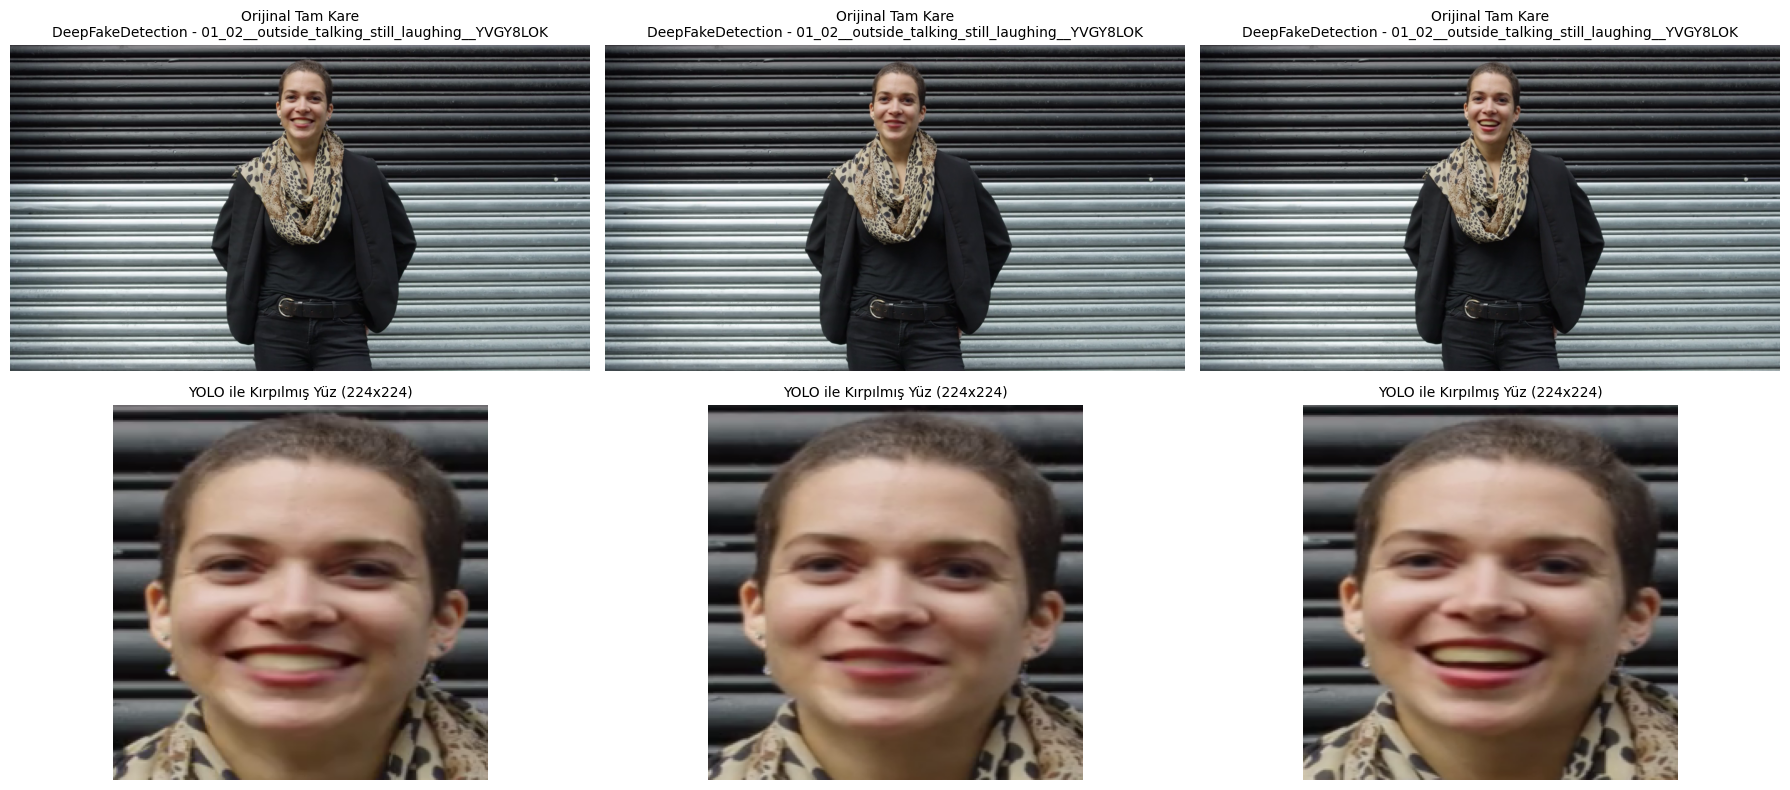

In [ ]:
import os
import sys
import glob
import cv2
import urllib.request
import shutil
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ==============================================================================
# 0. EKSİK KÜTÜPHANELERİN OTOMATİK KURULUMU
# ==============================================================================
try:
    from ultralytics import YOLO
    from decord import VideoReader, cpu
except ImportError:
    print("[BİLGİ] Gerekli kütüphaneler kuruluyor...")
    os.system('pip install -q ultralytics decord')
    from ultralytics import YOLO
    from decord import VideoReader, cpu
    print("[BİLGİ] Kurulum tamamlandı!\n")

# ==============================================================================
# 1. ORTAM VE MODEL KURULUMU (A100 OPTİMİZASYONLU)
# ==============================================================================
print("="*70)
print("FAZ 3: YÜZ ÇIKARMA VE VERİ SETİ HAZIRLAMA (KOPYALA-İŞLE-SİL MANTIĞI)")
print("="*70)

weights_path = 'yolov8n-face.pt'
if not os.path.exists(weights_path):
    print("[BİLGİ] YOLOv8-Face ağırlıkları indiriliyor...")
    url = "https://huggingface.co/junjiang/GestureFace/resolve/main/yolov8n-face.pt"
    urllib.request.urlretrieve(url, weights_path)

model = YOLO(weights_path)
model.to('cuda')
model.half()  # A100 için kalıcı FP16 formatı (Uyarıları engeller ve hızlandırır)
print("[BİLGİ] Model 'cuda' cihazına yüklendi, FP16'ya çevrildi ve A100 için hazır.")

# ==============================================================================
# 2. ANA İŞLEME FONKSİYONU VE LOGLAMA
# ==============================================================================
def process_and_crop_faces_all(input_base_dir, output_base_dir, margin_ratio=0.2, target_size=(224, 224), frame_skip=5):
    BATCH_SIZE = 512
    CHUNK_SIZE = 1000
    TEMP_VIDEO_PATH = '/content/temp_video.mp4' # Geçiçi yerel çalışma dosyası

    methods = ['original', 'DeepFakeDetection', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
    vis_examples = []

    stats = {
        m: {'bulunan_video': 0, 'islenen_video': 0, 'okunan_kare': 0, 'kaydedilen_yuz': 0, 'hata_sayisi': 0}
        for m in methods
    }

    start_time_total = time.time()

    for method in methods:
        method_in_dir = os.path.join(input_base_dir, method)
        method_out_dir = os.path.join(output_base_dir, method)
        os.makedirs(method_out_dir, exist_ok=True)

        videos = glob.glob(os.path.join(method_in_dir, '**', '*.mp4'), recursive=True)
        stats[method]['bulunan_video'] = len(videos)

        if not videos:
            print(f"\n[UYARI] {method} kategorisinde hiç video bulunamadı. Aranan yol: {method_in_dir}")
            continue

        print(f"\n[{method.upper()}] İşlemi Başladı | Toplam Video: {len(videos)}")

        for vid_path in tqdm(videos, desc=f"İşleniyor: {method}", leave=False):
            video_name = os.path.basename(vid_path).split('.')[0]
            done_flag = os.path.join(method_out_dir, f"{video_name}.done")

            if os.path.exists(done_flag):
                stats[method]['islenen_video'] += 1
                continue

            try:
                # ---------------------------------------------------------
                # YENİ MANTIK: VİDEOYU COLAB SSD'SİNE KOPYALA
                # ---------------------------------------------------------
                shutil.copy2(vid_path, TEMP_VIDEO_PATH)

                # Artık Drive üzerinden değil, saniyede GB'larca veri okuyabilen Colab yerel diskinden okuyoruz
                vr = VideoReader(TEMP_VIDEO_PATH, ctx=cpu(0))
                frame_indices = list(range(0, len(vr), frame_skip))
                stats[method]['okunan_kare'] += len(frame_indices)

                for c in range(0, len(frame_indices), CHUNK_SIZE):
                    chunk_indices = frame_indices[c:c + CHUNK_SIZE]
                    frames = vr.get_batch(chunk_indices).asnumpy()

                    for i in range(0, len(frames), BATCH_SIZE):
                        batch_frames = frames[i:i + BATCH_SIZE]
                        actual_indices = chunk_indices[i:i + BATCH_SIZE]

                        batch_bgr = [cv2.cvtColor(f, cv2.COLOR_RGB2BGR) for f in batch_frames]
                        results = model.predict(batch_bgr, verbose=False, device='cuda')

                        for batch_idx, result in enumerate(results):
                            frame_idx = actual_indices[batch_idx]
                            orig_frame = batch_bgr[batch_idx]

                            for box_idx, box in enumerate(result.boxes.xyxy):
                                x1, y1, x2, y2 = map(int, box.tolist())
                                w, h = x2 - x1, y2 - y1

                                x1 = max(0, int(x1 - margin_ratio * w))
                                y1 = max(0, int(y1 - margin_ratio * h))
                                x2 = min(orig_frame.shape[1], int(x2 + margin_ratio * w))
                                y2 = min(orig_frame.shape[0], int(y2 + margin_ratio * h))

                                face_crop = orig_frame[y1:y2, x1:x2]
                                if face_crop.size != 0:
                                    face_resized = cv2.resize(face_crop, target_size)
                                    out_name = f"{video_name}_kare{frame_idx:04d}_yuz{box_idx}.jpg"
                                    out_path = os.path.join(method_out_dir, out_name)

                                    cv2.imwrite(out_path, face_resized)
                                    stats[method]['kaydedilen_yuz'] += 1

                                    if len(vis_examples) < 3 and box_idx == 0 and method != 'original':
                                        vis_examples.append({
                                            'orig': cv2.cvtColor(orig_frame, cv2.COLOR_BGR2RGB),
                                            'crop': cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB),
                                            'title': f"{method} - {video_name}"
                                        })

                with open(done_flag, 'w') as f:
                    f.write('tamamlandi')
                stats[method]['islenen_video'] += 1

            except Exception as e:
                stats[method]['hata_sayisi'] += 1
                print(f"\n[HATA] Video: {video_name} okunamadı/işlenemedi! Detay: {str(e)}")
            finally:
                # ---------------------------------------------------------
                # YENİ MANTIK: İŞLEM BİTİNCE VEYA HATA ALINCA VİDEOYU SİL
                # ---------------------------------------------------------
                if os.path.exists(TEMP_VIDEO_PATH):
                    os.remove(TEMP_VIDEO_PATH)

    total_time = time.time() - start_time_total
    hours, rem = divmod(total_time, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\n[BİLGİ] Tüm Yüz Çıkarma İşlemleri {int(hours)} saat {int(minutes)} dk {int(seconds)} sn sürdü.")

    return stats, vis_examples

# ==============================================================================
# 3. İŞLEMİ BAŞLATMA VE RAPORLAMA
# ==============================================================================
INPUT_DIR = '/content/drive/MyDrive/FaceForensics++/data/raw/FaceForensics++_C23'
LOCAL_OUTPUT_DIR = '/content/Processed_Faces'
PROJECT_ROOT = '/content/drive/MyDrive/FaceForensics++'

stats_dict, examples = process_and_crop_faces_all(INPUT_DIR, LOCAL_OUTPUT_DIR)

print("\n" + "="*80)
print("FAZ 3: ÜRETİM ÖZET RAPORU")
print("="*80)
df_stats = pd.DataFrame.from_dict(stats_dict, orient='index')
df_stats.columns = ['Bulunan Video', 'İşlenen Video', 'Taranan Kare', 'Kaydedilen Yüz (Resim)', 'Hatalı Video']
print(df_stats.to_markdown())
print("="*80)

# ==============================================================================
# 4. DRIVE'A ARŞİVLEME (I/O DARBOĞAZINI ENGELLEME)
# ==============================================================================
DRIVE_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data/processed')
ZIP_FILE_PATH = os.path.join(DRIVE_OUTPUT_DIR, 'processed_faces.zip')

print(f"\n[BİLGİ] Resimler tek bir ZIP dosyası haline getirilip Drive'a aktarılıyor...")
print(f"[BİLGİ] Hedef Yol: {ZIP_FILE_PATH}")

os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
shutil.make_archive(ZIP_FILE_PATH.replace('.zip', ''), 'zip', LOCAL_OUTPUT_DIR)

print("\n[BAŞARILI] Arşivleme tamamlandı! Veri seti artık eğitime (Faz 4) hazır.")

# ==============================================================================
# 5. GÖRSELLEŞTİRME MATRİSİ (KONTROL İÇİN)
# ==============================================================================
if len(examples) > 0:
    print("\n[BİLGİ] Örnek Çıktılar Kaydediliyor ve Gösteriliyor...")
    fig, axes = plt.subplots(2, len(examples), figsize=(6 * len(examples), 8))

    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(len(examples)):
        axes[0, i].imshow(examples[i]['orig'])
        axes[0, i].set_title(f"Orijinal Tam Kare\n{examples[i]['title']}", fontsize=10)
        axes[0, i].axis('off')

        axes[1, i].imshow(examples[i]['crop'])
        axes[1, i].set_title("YOLO ile Kırpılmış Yüz (224x224)", fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('yuz_kirpma_matris.png', dpi=300)
    plt.show()

# Faz 4: Çoklu Model Eğitimi, Kapsamlı Karşılaştırma ve Hata Analizi

## FAZ 4 – KOD 1/2: VERİ HAZIRLAMA + MODEL EĞİTİMİ

In [ ]:
"""
================================================================================
KOD 1/2  —  NİHAİ MODEL EĞİTİMİ (Faz 4 - RAM Çökme Korumalı, Stabil Hız)
================================================================================
BU KODU ÇALIŞTIRMADAN ÖNCE (Colab hücresi):
    !pip install -q "timm==1.0.9" "albumentations>=1.4.0,<2.0" scikit-learn \
        pandas matplotlib seaborn tqdm grad-cam

    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
================================================================================
"""

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import re
import io
import json
import time
import copy
import glob
import zipfile
import shutil
import gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    pass

# ==============================================================================
# 0. GENEL AYARLAR
# ==============================================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAMES = ['convnext', 'efficientnet', 'mobilenet', 'resnet50', 'xception']

BATCH_SIZE = 384        # RAM aşımını önlemek için 512'den 384'e çekildi
EPOCHS = 20
PATIENCE = 5
LR_HEAD = 1e-4
LR_BASE = 1e-5
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 8         # Sistem RAM'i şişmemesi için 16'dan 8'e düşürüldü
GRAD_CLIP_NORM = 1.0

# HIZLANDIRMA: Her epokta eğitim verisinin %50'si kullanılır
EPOCH_DATA_RATIO = 0.50

RUN_LOMO = True
LOMO_HOLDOUT_METHODS = ['NeuralTextures']
LOMO_EPOCHS = 4
LOMO_PATIENCE = 1

USE_CHANNELS_LAST = True
USE_TORCH_COMPILE = False

FREEZE_RATIO = 0.0
FORENSIC_JPEG_QUALITY = 75

# ==============================================================================
# 1. ORTAM VE DİZİN YAPILANDIRMASI
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

AMP_DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and torch.cuda.is_available()

DRIVE_DIR = '/content/drive/MyDrive/FaceForensics++'
WEIGHTS_DIR = os.path.join(DRIVE_DIR, 'weights')
SPLITS_DIR = os.path.join(DRIVE_DIR, 'splits')
PLOTS_DIR = os.path.join(DRIVE_DIR, 'plots')
FEAT_DIR = os.path.join(DRIVE_DIR, 'features_faz5')
LOCAL_DATA_DIR = '/content/dataset'
ZIP_PATH = os.path.join(DRIVE_DIR, 'data/processed/processed_faces.zip')
LOCAL_ZIP_PATH = '/content/processed_faces_temp.zip'

for d in [WEIGHTS_DIR, SPLITS_DIR, PLOTS_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)

def is_data_ready(data_dir):
    return os.path.exists(data_dir) and len(os.listdir(data_dir)) > 0

if not is_data_ready(LOCAL_DATA_DIR):
    try:
        print("[BİLGİ] Veriler yerel diske çıkarılıyor...")
        if not os.path.exists(LOCAL_ZIP_PATH):
            shutil.copy2(ZIP_PATH, LOCAL_ZIP_PATH)
        with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(LOCAL_DATA_DIR)
        if os.path.exists(LOCAL_ZIP_PATH):
            os.remove(LOCAL_ZIP_PATH)
        print("[BİLGİ] Veri çıkarma tamamlandı!")
    except OSError as e:
        if e.errno == 107:
            raise RuntimeError("Drive bağlantısı koptu. Runtime'ı yeniden başlatın.") from e
        raise e
else:
    print("[BİLGİ] Veriler halihazırda yerel diskte mevcut. Yeniden çıkarma işlemi ATLANDI!")

# ==============================================================================
# 2. KİMLİK-BAZLI BÖLME
# ==============================================================================
class UnionFind:
    def __init__(self): self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx != ry: self.parent[rx] = ry

def parse_filename_ids(fname):
    stem = os.path.splitext(fname)[0]
    if '_kare' in stem:
        video_part = stem.split('_kare')[0]
        frame_idx = int(stem.split('_kare')[1].split('_')[0])
    else:
        video_part, frame_idx = stem, 0
    tokens = [t for t in re.split(r'[_\-]', video_part) if t != '']
    return (tokens if tokens else ['unknown']), frame_idx

def prepare_datasets(base_dir, train_ratio=0.7, val_ratio=0.15, seed=SEED):
    methods = ['original', 'Deepfakes', 'Face2Face', 'FaceShifter', 'FaceSwap', 'NeuralTextures']
    records = []
    uf = UnionFind()

    for method in methods:
        folder = os.path.join(base_dir, method)
        if not os.path.isdir(folder): continue
        label = 0 if method == 'original' else 1
        for img_p in glob.iglob(os.path.join(folder, '*.jpg')):
            if os.path.getsize(img_p) < 100: continue
            fname = os.path.basename(img_p)
            ids, frame_idx = parse_filename_ids(fname)
            video_id = f"{method}____{'_'.join(ids)}"
            for id_ in ids: uf.find(id_)
            for i in range(len(ids) - 1): uf.union(ids[i], ids[i + 1])
            records.append({'path': img_p, 'label': label, 'method': method,
                             'video_id': video_id, 'frame_idx': frame_idx, 'identity_ids': ','.join(ids)})

    df = pd.DataFrame(records)
    if df.empty: raise RuntimeError(f"Görüntü bulunamadı.")

    df['identity_group'] = df['identity_ids'].apply(lambda s: uf.find(s.split(',')[0]))
    groups = df['identity_group'].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(groups)

    n_train, n_val = int(len(groups) * train_ratio), int(len(groups) * (train_ratio + val_ratio))
    train_df = df[df['identity_group'].isin(set(groups[:n_train]))].reset_index(drop=True)
    val_df = df[df['identity_group'].isin(set(groups[n_train:n_val]))].reset_index(drop=True)
    test_df = df[df['identity_group'].isin(set(groups[n_val:]))].reset_index(drop=True)

    return train_df, val_df, test_df

train_df, val_df, test_df = prepare_datasets(LOCAL_DATA_DIR)

print("\n" + "="*80)
print("🚀 EĞİTİM BAŞLATILMADAN ÖNCE SİSTEM ÖZETİ")
print("="*80)
total_imgs = len(train_df) + len(val_df) + len(test_df)
print(f"   Toplam Temizlenmiş Görüntü: {total_imgs:,}")
for name, split_df in [("Eğitim (Train)", train_df), ("Doğrulama (Val)", val_df), ("Test (Test)", test_df)]:
    real_c = len(split_df[split_df['label'] == 0])
    fake_c = len(split_df[split_df['label'] == 1])
    print(f"   [{name}] -> Toplam: {len(split_df):,} | Gerçek: {real_c:,} | Sahte: {fake_c:,}")

print(f"\n🔹 HİPERPARAMETRELER VE DONANIM:")
print(f"   * Epoch: {EPOCHS} | Batch: {BATCH_SIZE} | Workers: {NUM_WORKERS} (RAM Optimizasyonu aktif)")
print(f"   * Öğrenme Hızı: Backbone={LR_BASE}, Head={LR_HEAD}")
print(f"   * Epok Veri Tüketimi: %{int(EPOCH_DATA_RATIO*100)}")
print("="*80 + "\n")
gc.collect()

# ==============================================================================
# 3. VERİ ARTIRMA VE DATALOADER
# ==============================================================================
def safe_forensic_compression(quality=75, p=1.0):
    try: return A.ImageCompression(quality_range=(quality, quality), p=p)
    except TypeError: return A.ImageCompression(quality_lower=quality, quality_upper=quality, p=p)

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.ImageCompression(quality_lower=50, quality_upper=90, p=1.0) if hasattr(A, 'ImageCompression') and 'quality_lower' in A.ImageCompression.__init__.__code__.co_varnames else A.ImageCompression(quality_range=(50, 90), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.15),
    A.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, p=0.1),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

eval_transforms = A.Compose([
    safe_forensic_compression(FORENSIC_JPEG_QUALITY, p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class FFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image_np = cv2.imread(row['path'])
            if image_np is None: raise ValueError()
            image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        except Exception:
            return self.__getitem__(np.random.randint(0, len(self.df)))
        if self.transform: image_np = self.transform(image=image_np)['image']
        return (image_np, torch.tensor(row['label'], dtype=torch.float32),
                str(row['method']), str(row['path']), str(row['video_id']), int(row['frame_idx']))

def get_balanced_sampler(df, ratio=1.0):
    counts = df['label'].value_counts()
    weights = df['label'].map(lambda l: 1.0 / counts[l]).values.astype(np.float64)
    n_samples = int(len(weights) * ratio)
    return WeightedRandomSampler(weights, num_samples=n_samples, replacement=True)

# prefetch_factor 4'ten 2'ye indirildi. RAM şişmesi tamamen engellenecek.
train_loader = DataLoader(FFDataset(train_df, train_transforms), batch_size=BATCH_SIZE,
                           sampler=get_balanced_sampler(train_df, ratio=EPOCH_DATA_RATIO),
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, persistent_workers=True, prefetch_factor=2)

train_eval_loader = DataLoader(FFDataset(train_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader = DataLoader(FFDataset(val_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader = DataLoader(FFDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, prefetch_factor=2)

# ==============================================================================
# 4. MODEL İNŞASI
# ==============================================================================
def build_model(model_name, pretrained=True):
    if model_name == 'convnext': m = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=1, drop_rate=0.1)
    elif model_name == 'efficientnet': m = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=1, drop_rate=0.1)
    elif model_name == 'xception': m = timm.create_model('legacy_xception', pretrained=pretrained, num_classes=1, drop_rate=0.1)
    elif model_name == 'mobilenet':
        w = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        m = models.mobilenet_v3_large(weights=w)
        m.classifier[2] = nn.Dropout(p=0.1, inplace=True)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, 1)
    elif model_name == 'resnet50':
        w = models.ResNet50_Weights.DEFAULT if pretrained else None
        m = models.resnet50(weights=w)
        m.fc = nn.Sequential(nn.Dropout(0.1), nn.Linear(m.fc.in_features, 1))

    for p in m.parameters(): p.requires_grad = True
    m = m.to(device)
    if USE_CHANNELS_LAST and device.type == 'cuda': m = m.to(memory_format=torch.channels_last)
    return m

def load_state_dict_safely(model, path):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    getattr(model, '_orig_mod', model).load_state_dict(ckpt['state_dict'], strict=True)
    return ckpt

# ==============================================================================
# 5. METRİKLER VE YARDIMCI FONKSİYONLAR
# ==============================================================================
def find_best_threshold(y_true, y_prob):
    best_threshold, best_f1 = 0.5, 0.0
    for threshold in np.arange(0.05, 0.96, 0.01):
        preds = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, preds, average='macro', zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = score, threshold
    return best_threshold, best_f1

def calculate_video_level_metrics(y_true, y_prob, video_ids, threshold=0.5):
    df_eval = pd.DataFrame({'video_id': video_ids, 'prob': y_prob, 'label': y_true})
    video_scores = df_eval.groupby('video_id').agg({'prob': 'mean', 'label': 'first'}).reset_index()
    v_preds = (video_scores['prob'] >= threshold).astype(int)
    v_f1 = f1_score(video_scores['label'], v_preds, average='macro', zero_division=0)
    return v_f1, len(video_scores)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_pred = (y_prob >= 0.5).astype(int)
    confidences = np.where(y_pred == 1, y_prob, 1.0 - y_prob)
    accuracies = (y_pred == y_true).astype(float)
    bin_limits = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = np.where((confidences >= bin_limits[i]) & (confidences <= bin_limits[i+1]))[0]
        if len(in_bin) > 0: ece += np.abs(np.mean(accuracies[in_bin]) - np.mean(confidences[in_bin])) * len(in_bin) / len(y_true)
    return ece

def evaluate_metrics(loader, model, criterion, use_optimal_threshold=False, saved_threshold=0.5):
    model.eval()
    total_loss, all_labels, all_probs, all_methods, all_paths = 0.0, [], [], [], []
    all_video_ids, all_frame_idx = [], []

    with torch.no_grad():
        for images, labels, methods, paths, video_ids, frame_idx in loader:
            images = images.to(device, non_blocking=True)
            if USE_CHANNELS_LAST and device.type == 'cuda': images = images.to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)
            with torch.amp.autocast(AMP_DEVICE_TYPE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)
                probs = torch.sigmoid(logits)
            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.float().cpu().numpy().flatten())
            all_methods.extend(methods)
            all_paths.extend(paths)
            all_video_ids.extend(video_ids)
            all_frame_idx.extend(frame_idx.numpy() if torch.is_tensor(frame_idx) else frame_idx)

    y_true, y_prob = np.array(all_labels), np.array(all_probs)

    if use_optimal_threshold:
        threshold, opt_f1 = find_best_threshold(y_true, y_prob)
    else:
        threshold = saved_threshold

    y_pred = (y_prob >= threshold).astype(int)

    try: auc_score = roc_auc_score(y_true, y_prob)
    except ValueError: auc_score = 0.0

    v_f1, num_videos = calculate_video_level_metrics(y_true, y_prob, np.array(all_video_ids), threshold)

    # RAM'i korumak için gereksiz listeleri anında yok et
    del all_labels, all_probs, all_methods, all_paths, all_video_ids, all_frame_idx
    gc.collect()

    return {
        'loss': total_loss / len(loader.dataset), 'acc': accuracy_score(y_true, y_pred),
        'prec': precision_score(y_true, y_pred, zero_division=0), 'rec': recall_score(y_true, y_pred, zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0), 'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'auc': auc_score, 'ece': expected_calibration_error(y_true, y_prob),
        'labels': y_true, 'preds': y_pred, 'probs': y_prob, 'video_level_f1': v_f1,
        'optimal_threshold': threshold, 'num_videos': num_videos
    }

def measure_speed(model, sample_shape=(1, 3, 224, 224), runs=200):
    model.eval()
    dummy = torch.randn(sample_shape).to(device)
    if USE_CHANNELS_LAST and device.type == 'cuda': dummy = dummy.to(memory_format=torch.channels_last)
    with torch.no_grad():
        for _ in range(20): _ = model(dummy)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        start = time.time()
        for _ in range(runs): _ = model(dummy)
        if torch.cuda.is_available(): torch.cuda.synchronize()
    return (time.time() - start) / runs * 1000.0, runs / (time.time() - start)

# ==============================================================================
# 6. EĞİTİM FONKSİYONU
# ==============================================================================
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR

def train_model(model_name, train_loader_, val_loader_, epochs, patience):
    model = build_model(model_name, pretrained=True)
    criterion = nn.BCEWithLogitsLoss()

    head_params, base_params = [], []
    for name, p in model.named_parameters():
        if any(nd in name for nd in ['head', 'fc', 'classifier']):
            head_params.append(p)
        else:
            base_params.append(p)

    optimizer = torch.optim.AdamW([
        {'params': base_params, 'lr': LR_BASE},
        {'params': head_params, 'lr': LR_HEAD}
    ], weight_decay=WEIGHT_DECAY)

    warmup_epochs = 2
    cosine_epochs = epochs - warmup_epochs
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: (epoch + 1) / warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

    scaler = torch.amp.GradScaler(AMP_DEVICE_TYPE, enabled=USE_SCALER)

    hist = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1, best_weights, epochs_no_improve = -1.0, None, 0
    best_threshold = 0.5

    for epoch in range(epochs):
        model.train()
        running_loss, all_probs, all_labels = 0.0, [], []

        current_lr_head = optimizer.param_groups[1]['lr']
        pbar = tqdm(train_loader_, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} (Head LR={current_lr_head:.2e})", leave=False, unit="batch")

        for images, labels, *_ in pbar:
            images = images.to(device, non_blocking=True)
            if USE_CHANNELS_LAST and device.type == 'cuda': images = images.to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(AMP_DEVICE_TYPE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)

            if USE_SCALER:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.float().detach().cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

        scheduler.step()

        t_loss = running_loss / (len(train_loader_) * BATCH_SIZE)

        val_res = evaluate_metrics(val_loader_, model, criterion, use_optimal_threshold=True)
        current_threshold = val_res['optimal_threshold']

        t_preds = (np.array(all_probs) >= current_threshold).astype(int)
        t_f1 = f1_score(all_labels, t_preds, average='macro', zero_division=0)

        hist['train_loss'].append(t_loss)
        hist['val_loss'].append(val_res['loss'])
        hist['train_f1'].append(t_f1)
        hist['val_f1'].append(val_res['macro_f1'])

        gap = t_f1 - val_res['macro_f1']

        print(f"[{model_name}] Epoch {epoch+1}:")
        print(f"   Train -> Loss: {t_loss:.4f} | F1: {t_f1:.4f}")
        print(f"   Val   -> Loss: {val_res['loss']:.4f} | F1: {val_res['macro_f1']:.4f} | AUC: {val_res['auc']:.4f} | ECE: {val_res['ece']:.4f}")
        print(f"   Gap   -> Train-Val F1 Gap: {gap:.4f} | Vid F1: {val_res['video_level_f1']:.4f} | Opt_Thr: {current_threshold:.2f}")

        if val_res['macro_f1'] > best_val_f1:
            best_val_f1 = val_res['macro_f1']
            best_threshold = current_threshold
            best_weights = copy.deepcopy(getattr(model, '_orig_mod', model).state_dict())
            epochs_no_improve = 0
            print(f"   => [YENİ EN İYİ MODEL] Frame F1: {best_val_f1:.4f} kaydedildi.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n[DURDURULDU] {patience} epok boyunca Frame F1'de gelişim olmadı.")
                break

        del all_probs, all_labels, val_res
        torch.cuda.empty_cache()
        gc.collect()

    getattr(model, '_orig_mod', model).load_state_dict(best_weights or getattr(model, '_orig_mod', model).state_dict())
    return model, hist, best_val_f1, best_threshold

# ==============================================================================
# 7. EĞİTİM, ŞAMPİYON SEÇİMİ VE TABLOLAR
# ==============================================================================
history_all, best_val_f1_all, trained_models, optimal_thresholds = {}, {}, {}, {}

for m_name in MODEL_NAMES:
    print(f"\n{'='*70}\n EĞİTİM BAŞLIYOR: {m_name.upper()}\n{'='*70}")
    model, hist, best_val_f1, best_thr = train_model(m_name, train_loader, val_loader, EPOCHS, PATIENCE)

    print("\n[BİLGİ] Eğitim tamamlandı. Nihai Validation Threshold belirleniyor...")
    val_final = evaluate_metrics(val_loader, model, nn.BCEWithLogitsLoss(), use_optimal_threshold=True)
    opt_thr = val_final['optimal_threshold']
    print(f"[OPTİMAL THRESHOLD] {opt_thr:.2f}")

    history_all[m_name] = hist
    best_val_f1_all[m_name] = best_val_f1
    trained_models[m_name] = model
    optimal_thresholds[m_name] = opt_thr

    torch.save({'model_name': m_name, 'state_dict': getattr(model, '_orig_mod', model).state_dict(),
                'img_size': 224, 'val_frame_f1': best_val_f1, 'optimal_threshold': opt_thr},
                os.path.join(WEIGHTS_DIR, f"{m_name}_best.pth"))

    del val_final
    torch.cuda.empty_cache()
    gc.collect()

champion_name = max(best_val_f1_all, key=best_val_f1_all.get)
champion_thr = optimal_thresholds[champion_name]
print(f"\n[ŞAMPİYON] Seçilen model: {champion_name.upper()} (Frame F1={best_val_f1_all[champion_name]:.4f}, Opt_Thr={champion_thr:.2f})")

with open(os.path.join(WEIGHTS_DIR, 'champion.json'), 'w') as f:
    json.dump({'champion': champion_name, 'val_frame_f1': best_val_f1_all[champion_name], 'optimal_threshold': champion_thr}, f, indent=2)

summary_rows = []
for m_name in MODEL_NAMES:
    model = trained_models[m_name]
    thr = optimal_thresholds[m_name]
    criterion = nn.BCEWithLogitsLoss()

    tr_res = evaluate_metrics(train_eval_loader, model, criterion, saved_threshold=thr)
    va_res = evaluate_metrics(val_loader, model, criterion, saved_threshold=thr)
    te_res = evaluate_metrics(test_loader, model, criterion, saved_threshold=thr)
    latency, fps = measure_speed(model)

    summary_rows.append({
        'Model': m_name.upper(),
        'Optimal Thr': thr,
        'Val Frame F1': va_res['macro_f1'],
        'Val Video F1': va_res['video_level_f1'],
        'Test Frame F1': te_res['macro_f1'],
        'Test Video F1': te_res['video_level_f1'],
        'Test AUC': te_res['auc'],
        'Test Prec': te_res['prec'],
        'Test Rec': te_res['rec'],
        'Test ECE': te_res['ece'],
        'Latency (ms)': latency,
        'FPS': fps
    })
    del tr_res, va_res, te_res
    torch.cuda.empty_cache()
    gc.collect()

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(WEIGHTS_DIR, 'summary_table.csv'), index=False)
print("\n[ÖZET TABLO (Optimal Threshold ile Test Edildi)]\n", summary_df.round(4).to_string(index=False))

# ==============================================================================
# 8. ÇAPRAZ-MANİPÜLASYON (LOMO) TESTİ
# ==============================================================================
if RUN_LOMO:
    for holdout_method in LOMO_HOLDOUT_METHODS:
        if holdout_method not in train_df['method'].unique(): continue
        print(f"\n{'='*70}\n LOMO TESTİ: '{holdout_method}' Hariç Eğitiliyor\n{'='*70}")

        lomo_train_df = train_df[train_df['method'] != holdout_method].reset_index(drop=True)
        lomo_val_df = val_df[val_df['method'] != holdout_method].reset_index(drop=True)

        l_train_loader = DataLoader(FFDataset(lomo_train_df, train_transforms), batch_size=BATCH_SIZE,
            sampler=get_balanced_sampler(lomo_train_df, ratio=EPOCH_DATA_RATIO), num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, prefetch_factor=2)
        l_val_loader = DataLoader(FFDataset(lomo_val_df, eval_transforms), batch_size=BATCH_SIZE,
            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

        lomo_model, _, lomo_best_f1, _ = train_model(champion_name, l_train_loader, l_val_loader, LOMO_EPOCHS, LOMO_PATIENCE)

        l_val_final = evaluate_metrics(l_val_loader, lomo_model, nn.BCEWithLogitsLoss(), use_optimal_threshold=True)
        lomo_thr = l_val_final['optimal_threshold']

        torch.save({'state_dict': getattr(lomo_model, '_orig_mod', lomo_model).state_dict(), 'optimal_threshold': lomo_thr},
                   os.path.join(WEIGHTS_DIR, f"lomo_{holdout_method}.pth"))

        holdout_fake_df = pd.concat([train_df, val_df, test_df])
        holdout_fake_df = holdout_fake_df[holdout_fake_df['method'] == holdout_method]
        holdout_real_df = test_df[test_df['method'] == 'original']
        lomo_eval_df = pd.concat([holdout_fake_df, holdout_real_df]).reset_index(drop=True)

        lomo_eval_loader = DataLoader(FFDataset(lomo_eval_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
        lomo_res = evaluate_metrics(lomo_eval_loader, lomo_model, nn.BCEWithLogitsLoss(), saved_threshold=lomo_thr)

        print(f"[LOMO SONUÇ] '{holdout_method}' Görülmedi -> Video F1={lomo_res['video_level_f1']:.4f} Frame F1={lomo_res['macro_f1']:.4f} AUC={lomo_res['auc']:.4f}")
        with open(os.path.join(WEIGHTS_DIR, f"lomo_{holdout_method}_results.json"), 'w') as f:
            json.dump({'holdout': holdout_method, 'video_level_f1': lomo_res['video_level_f1'], 'macro_f1': lomo_res['macro_f1'], 'auc': lomo_res['auc'], 'optimal_threshold': lomo_thr}, f)

        del lomo_model, l_val_final, lomo_res
        torch.cuda.empty_cache()
        gc.collect()

# ==============================================================================
# 9. XAI (GRAD-CAM) VE FAZ 5 İÇİN ÖZNİTELİK ÇIKARIMI
# ==============================================================================
print("\n[BİLGİ] Şampiyon Model İçin Hata Isı Haritaları (Saliency & Grad-CAM) Oluşturuluyor...")
champ_model = trained_models[champion_name]
champ_eval = evaluate_metrics(test_loader, champ_model, nn.BCEWithLogitsLoss(), saved_threshold=champion_thr)

def get_target_layer(m_name, model):
    m = getattr(model, '_orig_mod', model)
    if m_name == 'resnet50': return [m.layer4[-1]]
    elif m_name == 'mobilenet': return [m.features[-1]]
    elif m_name == 'efficientnet': return [m.blocks[-1]]
    elif m_name == 'convnext': return [m.stages[-1].blocks[-1]]
    else: return [list(m.children())[-2]]

try:
    cam = GradCAM(model=champ_model, target_layers=get_target_layer(champion_name, champ_model), use_cuda=True)
    errors = np.abs(champ_eval['labels'] - champ_eval['probs'])
    worst_indices = np.argsort(errors)[-3:][::-1]

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    for i, idx in enumerate(worst_indices):
        img_path_local = champ_eval['paths'][idx]
        rgb_img = cv2.cvtColor(cv2.imread(img_path_local), cv2.COLOR_BGR2RGB)
        rgb_img_float = np.float32(rgb_img) / 255
        input_tensor = eval_transforms(image=rgb_img)['image'].unsqueeze(0).to(device)

        axes[i, 0].imshow(rgb_img); axes[i, 0].set_title(f"Gerçek: {champ_eval['labels'][idx]} | Skor: {champ_eval['probs'][idx]:.2f}"); axes[i, 0].axis('off')

        input_tensor.requires_grad_()
        champ_model(input_tensor).backward()
        sal = torch.max(input_tensor.grad.data.abs(), dim=1)[0][0].cpu().numpy()
        axes[i, 1].imshow((sal - sal.min()) / (sal.max() - sal.min() + 1e-8), cmap='hot'); axes[i, 1].axis('off')

        axes[i, 2].imshow(show_cam_on_image(rgb_img_float, cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :], use_rgb=True)); axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'xai_analysis.png'))
    plt.show()
except Exception as e:
    print(f"XAI Görselleştirme sırasında hata: {e}")
finally:
    del champ_eval
    gc.collect()

print("\n[BİLGİ] Faz 5: Öznitelik Çıkarımı (Feature Extraction) Başlıyor...")
m_raw = getattr(champ_model, '_orig_mod', champ_model)
if champion_name == 'resnet50': m_raw.fc = nn.Identity()
elif champion_name == 'mobilenet': m_raw.classifier[3] = nn.Identity()
else: m_raw.reset_classifier(0)

def extract_and_save(loader, split_name):
    m_raw.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for images, labels, *_ in tqdm(loader, desc=f"{split_name} Özellikleri"):
            all_feats.append(m_raw(images.to(device)).cpu())
            all_labels.extend(labels.numpy())
    torch.save({'features': torch.cat(all_feats), 'labels': np.array(all_labels)}, os.path.join(FEAT_DIR, f"{split_name}_features.pt"))
    del all_feats, all_labels
    gc.collect()

extract_and_save(DataLoader(FFDataset(train_df, eval_transforms), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2), 'train')
extract_and_save(val_loader, 'val')
extract_and_save(test_loader, 'test')
print("[BAŞARILI] Tüm İşlemler Tamamlandı!")

[BİLGİ] Veriler halihazırda yerel diskte mevcut. Yeniden çıkarma işlemi ATLANDI!

🚀 EĞİTİM BAŞLATILMADAN ÖNCE SİSTEM ÖZETİ
   Toplam Temizlenmiş Görüntü: 791,011
   [Eğitim (Train)] -> Toplam: 571,054 | Gerçek: 101,811 | Sahte: 469,243
   [Doğrulama (Val)] -> Toplam: 113,677 | Gerçek: 20,047 | Sahte: 93,630
   [Test (Test)] -> Toplam: 106,280 | Gerçek: 19,403 | Sahte: 86,877

🔹 HİPERPARAMETRELER VE DONANIM:
   * Epoch: 20 | Batch: 384 | Workers: 8 (RAM Optimizasyonu aktif)
   * Öğrenme Hızı: Backbone=1e-05, Head=0.0001
   * Epok Veri Tüketimi: %50


 EĞİTİM BAŞLIYOR: CONVNEXT


[convnext] Epoch 1/20 (Head LR=5.00e-05):   0%|          | 0/743 [00:00<?, ?batch/s]

[convnext] Epoch 1:
   Train -> Loss: 0.3499 | F1: 0.7826
   Val   -> Loss: 0.3017 | F1: 0.8354 | AUC: 0.9178 | ECE: 0.0750
   Gap   -> Train-Val F1 Gap: -0.0528 | Vid F1: 0.9123 | Opt_Thr: 0.37
   => [YENİ EN İYİ MODEL] Frame F1: 0.8354 kaydedildi.


[convnext] Epoch 2/20 (Head LR=1.00e-04):   0%|          | 0/743 [00:00<?, ?batch/s]

[convnext] Epoch 2:
   Train -> Loss: 0.2631 | F1: 0.8017
   Val   -> Loss: 0.3605 | F1: 0.8438 | AUC: 0.9333 | ECE: 0.0497
   Gap   -> Train-Val F1 Gap: -0.0422 | Vid F1: 0.8634 | Opt_Thr: 0.09
   => [YENİ EN İYİ MODEL] Frame F1: 0.8438 kaydedildi.


...

[convnext] Epoch 4:
   Train -> Loss: 0.2049 | F1: 0.8472
   Val   -> Loss: 0.2198 | F1: 0.8940 | AUC: 0.9605 | ECE: 0.0364
   Gap   -> Train-Val F1 Gap: -0.0467 | Vid F1: 0.9395 | Opt_Thr: 0.23
   => [YENİ EN İYİ MODEL] Frame F1: 0.8940 kaydedildi.
[LOMO SONUÇ] 'NeuralTextures' Görülmedi -> Video F1=0.2786 Frame F1=0.3751 AUC=0.5666

[BİLGİ] Şampiyon Model İçin Hata Isı Haritaları (Saliency & Grad-CAM) Oluşturuluyor...
XAI Görselleştirme sırasında hata: name 'GradCAM' is not defined

[BİLGİ] Faz 5: Öznitelik Çıkarımı (Feature Extraction) Başlıyor...


train Özellikleri:   0%|          | 0/1488 [00:00<?, ?it/s]

val Özellikleri:   0%|          | 0/297 [00:00<?, ?it/s]

test Özellikleri:   0%|          | 0/277 [00:00<?, ?it/s]

[BAŞARILI] Tüm İşlemler Tamamlandı!


##  FAZ 4 – KOD 2/2: DEĞERLENDİRME + XAI + FAZ 5 ÖZNİTELİK

In [ ]:
"""
================================================================================
KOD 2/2  —  ŞAMPİYON MODEL DEĞERLENDİRMESİ, XAI VE ÖZNİTELİK ÇIKARIMI (Faz 4 Part 2)
================================================================================
BU KODU ÇALIŞTIRMADAN ÖNCE (Colab hücresi):
    !pip install -q "timm==1.0.9" "albumentations>=1.4.0,<2.0" scikit-learn \
        pandas matplotlib seaborn tqdm grad-cam

    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
================================================================================
"""

import os
import gc
import json
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# OPENCV RAM SIZINTISI KALKANI
cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report)

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    print("[UYARI] grad-cam kütüphanesi eksik! Hücrede '!pip install grad-cam' çalıştırın.")

# ==============================================================================
# 0. GENEL AYARLAR VE DİZİNLER
# ==============================================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

BATCH_SIZE = 512
NUM_WORKERS = 8
FORENSIC_JPEG_QUALITY = 75

DRIVE_DIR = '/content/drive/MyDrive/FaceForensics++'
WEIGHTS_DIR = os.path.join(DRIVE_DIR, 'weights')
SPLITS_DIR = os.path.join(DRIVE_DIR, 'splits')
PLOTS_DIR = os.path.join(DRIVE_DIR, 'plots')
FEAT_DIR = os.path.join(DRIVE_DIR, 'features_faz5')

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(FEAT_DIR, exist_ok=True)

sns.set_theme(style="darkgrid", context="paper")
plt.rcParams['font.size'] = 12

print("="*80)
print("🚀 FAZ 4 - BÖLÜM 2: ŞAMPİYON MODEL ÖZEL ANALİZİ VE ÖZNİTELİK ÇIKARIMI")
print("="*80)

# Şampiyon Modeli Tespit Et
try:
    with open(os.path.join(WEIGHTS_DIR, 'champion.json'), 'r') as f:
        champ_data = json.load(f)
        CHAMPION_NAME = champ_data['champion']
    print(f"🏆 ŞAMPİYON MODEL BULUNDU: {CHAMPION_NAME.upper()}")
except FileNotFoundError:
    raise FileNotFoundError("champion.json bulunamadı! Önce eğitim kodunu (1/2) çalıştırmalısınız.")

# ==============================================================================
# 1. VERİ YÜKLEME VE DATALOADER İNŞASI
# ==============================================================================
def safe_image_compression(lower, upper, p=1.0):
    try:
        return A.ImageCompression(quality_range=(lower, upper), p=p)
    except TypeError:
        return A.ImageCompression(quality_lower=lower, quality_upper=upper, p=p)

eval_transforms = A.Compose([
    safe_image_compression(FORENSIC_JPEG_QUALITY, FORENSIC_JPEG_QUALITY, p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class FFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image_np = cv2.imread(row['path'])
            if image_np is None: raise ValueError()
            image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        except Exception:
            return self.__getitem__(np.random.randint(0, len(self.df)))
        if self.transform: image_np = self.transform(image=image_np)['image']
        return (image_np, torch.tensor(row['label'], dtype=torch.float32),
                str(row['method']), str(row['path']), str(row['video_id']))

print("[BİLGİ] Veri setleri yükleniyor (low_memory=False)...")
train_df = pd.read_csv(os.path.join(SPLITS_DIR, 'train_df.csv'), low_memory=False)
val_df = pd.read_csv(os.path.join(SPLITS_DIR, 'val_df.csv'), low_memory=False)
test_df = pd.read_csv(os.path.join(SPLITS_DIR, 'test_df.csv'), low_memory=False)

test_loader = DataLoader(FFDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, prefetch_factor=2)

# ==============================================================================
# 2. MODEL İNŞA VE TAHMİN FONKSİYONU
# ==============================================================================
def build_model(model_name):
    if model_name == 'convnext': m = timm.create_model('convnext_tiny', pretrained=False, num_classes=1)
    elif model_name == 'efficientnet': m = timm.create_model('efficientnet_b0', pretrained=False, num_classes=1)
    elif model_name == 'xception': m = timm.create_model('legacy_xception', pretrained=False, num_classes=1)
    elif model_name == 'mobilenet':
        m = models.mobilenet_v3_large(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, 1)
    elif model_name == 'resnet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, 1))
    return m.to(device)

def get_predictions(model, loader):
    model.eval()
    all_labels, all_probs, all_methods, all_paths, all_vids = [], [], [], [], []
    with torch.no_grad():
        for images, labels, methods, paths, vids in tqdm(loader, desc="Test Verisi İşleniyor", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(images)
                probs = torch.sigmoid(logits)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.float().cpu().numpy().flatten())
            all_methods.extend(methods)
            all_paths.extend(paths)
            all_vids.extend(vids)
    return np.array(all_labels), np.array(all_probs), np.array(all_methods), np.array(all_paths), np.array(all_vids)

# ==============================================================================
# 3. ŞAMPİYON MODEL DEĞERLENDİRMESİ
# ==============================================================================
model_path = os.path.join(WEIGHTS_DIR, f"{CHAMPION_NAME}_best.pth")
ckpt = torch.load(model_path, map_location=device, weights_only=False)
opt_thr = ckpt.get('optimal_threshold', 0.5)

model = build_model(CHAMPION_NAME)
model.load_state_dict(ckpt['state_dict'], strict=True)

print(f"\n[BİLGİ] {CHAMPION_NAME.upper()} modeli Test verisinde değerlendiriliyor...")
y_true, y_prob, methods, paths, vids = get_predictions(model, test_loader)
y_pred = (y_prob >= opt_thr).astype(int)

auc_val = roc_auc_score(y_true, y_prob)
f1_val = f1_score(y_true, y_pred, average='macro')
acc_val = accuracy_score(y_true, y_pred)

print(f"✅ Değerlendirme Tamamlandı. (Threshold: {opt_thr:.2f} | Test AUC: {auc_val:.4f} | Test F1: {f1_val:.4f})")

# ==============================================================================
# KONSOL ÇIKTISI: CONFUSION MATRIX (KARMAŞIKLIK MATRİSİ)
# ==============================================================================
cm = confusion_matrix(y_true, y_pred)

print("\n" + "-"*60)
print(f"🧠 ŞAMPİYON ({CHAMPION_NAME.upper()}) KARMAŞIKLIK MATRİSİ (TEST SETİ)")
print("-"*60)
print(f"{'':<20} | {'Tahmin: Gerçek (0)':<20} | {'Tahmin: Sahte (1)':<20}")
print("-" * 65)
print(f"{'Gerçek (Orijinal)':<20} | {cm[0,0]:<20} | {cm[0,1]:<20}")
print(f"{'Sahte (Deepfake)':<20} | {cm[1,0]:<20} | {cm[1,1]:<20}")
print("-" * 65)

# ==============================================================================
# KONSOL ÇIKTISI: KATEGORİYE GÖRE DERİN ANALİZ
# ==============================================================================
df_res = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob, 'method': methods})

metrics_per_method = []
fake_methods = df_res[df_res['method'] != 'original']['method'].unique()

for method in fake_methods:
    df_m = df_res[(df_res['method'] == method) | (df_res['method'] == 'original')]
    if len(df_m) > 0 and len(df_m['y_true'].unique()) > 1:
        f1 = f1_score(df_m['y_true'], df_m['y_pred'], average='macro')
        auc = roc_auc_score(df_m['y_true'], df_m['y_prob'])
        acc = accuracy_score(df_m['y_true'], df_m['y_pred'])
        metrics_per_method.append({
            'Kategori (Manipülasyon)': method,
            'Accuracy': f"{acc:.4f}",
            'Macro F1': f"{f1:.4f}",
            'AUC': f"{auc:.4f}"
        })

print("\n" + "-"*60)
print(f"🎯 ŞAMPİYON ({CHAMPION_NAME.upper()}) KATEGORİ (MANİPÜLASYON) BAZLI BAŞARI")
print("-"*60)
df_metrics = pd.DataFrame(metrics_per_method)
print(df_metrics.to_string(index=False))
print("-"*60)

# ==============================================================================
# KONSOL ÇIKTISI: HATA ANALİZİ (EN KÖTÜ TAHMİNLER)
# ==============================================================================
print("\n" + "-"*60)
print("❌ ŞAMPİYON MODELİN KAFASINI EN ÇOK KARIŞTIRAN 5 ÖRNEK (HATA ANALİZİ)")
print("-"*60)
errors = np.abs(y_true - y_prob)
worst_idx = np.argsort(errors)[-5:][::-1]

for rank, i in enumerate(worst_idx, 1):
    file_name = os.path.basename(paths[i])
    true_label = "Sahte (1)" if y_true[i] == 1 else "Gerçek (0)"
    print(f"{rank}. Dosya: {file_name}")
    print(f"   Kategori   : {methods[i]}")
    print(f"   Gerçek     : {true_label}")
    print(f"   Model Skoru: {y_prob[i]:.4f} (Beklenen: {y_true[i]:.1f})\n")

# ==============================================================================
# 4. GRAFİKLERİ KAYDETME KISMI
# ==============================================================================
print("\n[ÇİZİM] Grafikler Drive'a kaydediliyor...")

# 1. ROC ve PR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax1.plot(fpr, tpr, label=f"{CHAMPION_NAME.upper()} (AUC = {auc_val:.4f})", color='b', linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('Test Seti: ROC Eğrisi', fontweight='bold')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax2.plot(rec, prec, label=f"{CHAMPION_NAME.upper()}", color='r', linewidth=2)
ax2.set_title('Test Seti: Precision-Recall Eğrisi', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CHAMPION_NAME}_roc_pr.png'), dpi=300, bbox_inches='tight')
plt.close()

# 2. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Gerçek', 'Sahte'], yticklabels=['Gerçek', 'Sahte'])
plt.title(f"{CHAMPION_NAME.upper()} Karmaşıklık Matrisi", fontweight='bold')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CHAMPION_NAME}_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.close()

# ==============================================================================
# 5. XAI: KATEGORİK GRAD-CAM (GÖRSEL AÇIKLANABİLİRLİK)
# ==============================================================================
print("[ÇİZİM] XAI (Grad-CAM) Şampiyon model için oluşturuluyor...")
def get_target_layer(m_name, m):
    if m_name == 'resnet50': return [m.layer4[-1]]
    elif m_name == 'mobilenet': return [m.features[-1]]
    elif m_name == 'efficientnet': return [m.blocks[-1]]
    elif m_name == 'convnext': return [m.stages[-1].blocks[-1]]
    else: return [list(m.children())[-2]]

cam = None
try:
    cam = GradCAM(model=model, target_layers=get_target_layer(CHAMPION_NAME, model), use_cuda=True)
    sample_paths = []

    # Her fake yönteminden doğru bildiği 1 sahte video örneği seç
    for method in fake_methods:
        correct_fakes = df_res[(df_res['method'] == method) & (df_res['y_true'] == 1) & (df_res['y_pred'] == 1)]
        if not correct_fakes.empty:
            sample_paths.append((method, paths[correct_fakes.index[0]]))

    # 1 tane de doğru bildiği gerçek (original) seç
    correct_reals = df_res[(df_res['method'] == 'original') & (df_res['y_true'] == 0) & (df_res['y_pred'] == 0)]
    if not correct_reals.empty:
        sample_paths.append(('Gerçek (Orijinal)', paths[correct_reals.index[0]]))

    n_samples = len(sample_paths)
    if n_samples > 0:
        fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
        for i, (method_name, img_path) in enumerate(sample_paths):
            rgb_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            rgb_img_float = np.float32(rgb_img) / 255
            input_tensor = eval_transforms(image=rgb_img)['image'].unsqueeze(0).to(device)

            axes[i, 0].imshow(rgb_img); axes[i, 0].set_title(f"Sınıf: {method_name}"); axes[i, 0].axis('off')

            grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]
            axes[i, 1].imshow(show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True))
            axes[i, 1].set_title("Modelin Odak Noktası (Grad-CAM)"); axes[i, 1].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, f'{CHAMPION_NAME}_xai_analysis.png'), dpi=300, bbox_inches='tight')
        plt.close()
        print("✅ XAI (Grad-CAM) başarıyla kaydedildi.")
except Exception as e:
    print(f"[HATA] XAI Çiziminde Sorun Oluştu: {e}")
finally:
    if cam is not None:
        del cam

# ==============================================================================
# 6. FAZ 5 İÇİN ÖZNİTELİK (FEATURE) ÇIKARIMI VE DRIVE'A KAYIT
# ==============================================================================
print("\n" + "="*80)
print("💾 FAZ 5 ÖN HAZIRLIĞI: ÖZNİTELİK VEKTÖRLERİ ÇIKARILIYOR")
print("="*80)

# Head katmanını çıkararak saf vektör elde ediyoruz
if CHAMPION_NAME == 'resnet50': model.fc = nn.Identity()
elif CHAMPION_NAME == 'mobilenet': model.classifier[3] = nn.Identity()
elif CHAMPION_NAME in ['convnext', 'efficientnet', 'xception']: model.reset_classifier(0)
else: model = nn.Sequential(*list(model.children())[:-1])

model.eval()

def extract_and_save_features(loader, split_name):
    print(f"-> {split_name.upper()} verisi için vektörler hesaplanıyor...")
    all_feats, all_labels, all_vids = [], [], []
    with torch.no_grad():
        for images, labels, _, _, vids in tqdm(loader, desc=f"{split_name} Features", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                features = model(images)
            if features.dim() > 2: features = torch.flatten(features, 1)
            all_feats.append(features.cpu())
            all_labels.extend(labels.numpy())
            all_vids.extend(vids)

    final_dict = {'features': torch.cat(all_feats), 'labels': np.array(all_labels), 'video_ids': np.array(all_vids)}
    save_path = os.path.join(FEAT_DIR, f"{split_name}_features_{CHAMPION_NAME}.pt")
    torch.save(final_dict, save_path)
    print(f"   [KAYDEDİLDİ] Boyut: {final_dict['features'].shape} | Yol: {save_path}")

train_feat_loader = DataLoader(FFDataset(train_df, eval_transforms), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)
val_feat_loader = DataLoader(FFDataset(val_df, eval_transforms), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

extract_and_save_features(train_feat_loader, 'train')
extract_and_save_features(val_feat_loader, 'val')
extract_and_save_features(test_loader, 'test')

print("\n" + "="*80)
print("🎉 TEBRİKLER! FAZ 4 TAMAMLANDI. FAZ 5'E GEÇMEYE HAZIRSINIZ.")
print("="*80)

[UYARI] grad-cam kütüphanesi eksik! Hücrede '!pip install grad-cam' çalıştırın.
🚀 FAZ 4 - BÖLÜM 2: ŞAMPİYON MODEL ÖZEL ANALİZİ VE ÖZNİTELİK ÇIKARIMI
🏆 ŞAMPİYON MODEL BULUNDU: CONVNEXT
[BİLGİ] Veri setleri yükleniyor (low_memory=False)...

[BİLGİ] CONVNEXT modeli Test verisinde değerlendiriliyor...


Test Verisi İşleniyor:   0%|          | 0/624 [00:00<?, ?it/s]

✅ Değerlendirme Tamamlandı. (Threshold: 0.22 | Test AUC: 0.9383 | Test F1: 0.7701)

------------------------------------------------------------
🧠 ŞAMPİYON (CONVNEXT) KARMAŞIKLIK MATRİSİ (TEST SETİ)
------------------------------------------------------------
                     | Tahmin: Gerçek (0)   | Tahmin: Sahte (1)   
-----------------------------------------------------------------
Gerçek (Orijinal)    | 13418                | 5926                
Sahte (Deepfake)     | 14001                | 285980              
-----------------------------------------------------------------

------------------------------------------------------------
🎯 ŞAMPİYON (CONVNEXT) KATEGORİ (MANİPÜLASYON) BAZLI BAŞARI
------------------------------------------------------------
Kategori (Manipülasyon) Accuracy Macro F1    AUC
      DeepFakeDetection   0.9238   0.7801 0.9342
              Deepfakes   0.8379   0.8344 0.9519
              Face2Face   0.8316   0.8291 0.9530
            FaceShifter   0.8

train Features:   0%|          | 0/1117 [00:00<?, ?it/s]

   [KAYDEDİLDİ] Boyut: torch.Size([571858, 768]) | Yol: /content/drive/MyDrive/FaceForensics++/features_faz5/train_features_convnext.pt
-> VAL verisi için vektörler hesaplanıyor...


val Features:   0%|          | 0/222 [00:01<?, ?it/s]

   [KAYDEDİLDİ] Boyut: torch.Size([113193, 768]) | Yol: /content/drive/MyDrive/FaceForensics++/features_faz5/val_features_convnext.pt
-> TEST verisi için vektörler hesaplanıyor...


test Features:   0%|          | 0/624 [00:00<?, ?it/s]

   [KAYDEDİLDİ] Boyut: torch.Size([319325, 768]) | Yol: /content/drive/MyDrive/FaceForensics++/features_faz5/test_features_convnext.pt

🎉 TEBRİKLER! FAZ 4 TAMAMLANDI. FAZ 5'E GEÇMEYE HAZIRSINIZ.


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=50c5406c0872e8d570433f616b4934fa88c99e138547c72370a3e78917f41306
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


🎨 GÖRSELLEŞTİRME VE XAI (GRAD-CAM) MOTORU BAŞLATILDI
🏆 ŞAMPİYON MODEL YÜKLENİYOR: CONVNEXT


Test Verisi Taranıyor:   0%|          | 0/1248 [00:00<?, ?it/s]


📊 1. ROC VE PRECISION-RECALL EĞRİLERİ


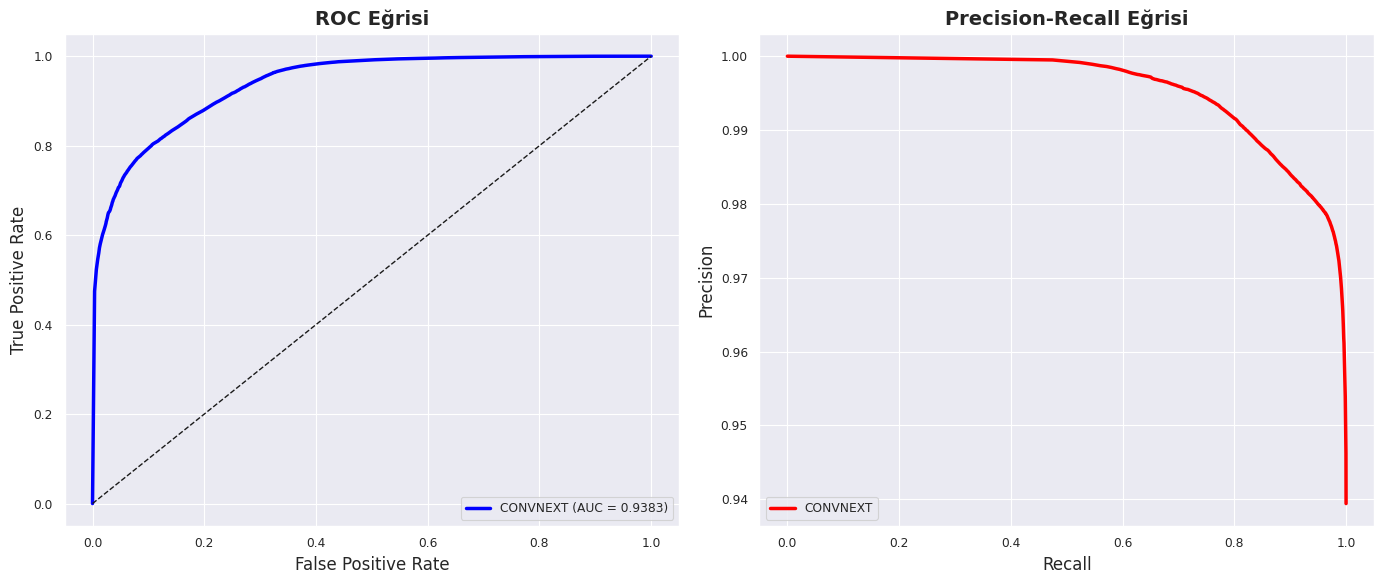


🧠 2. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)


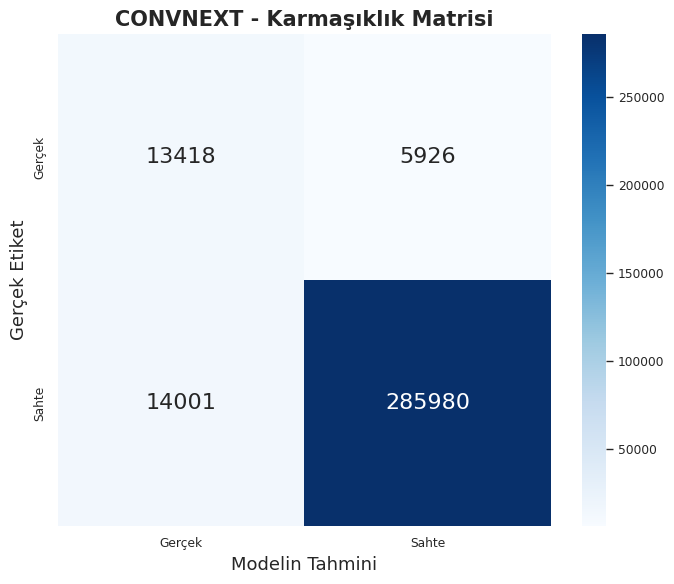


🎯 3. MANİPÜLASYON KATEGORİSİNE GÖRE BAŞARI ORANLARI


/tmp/ipykernel_95899/1982064391.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='AUC Skoru', data=df_metrics, palette='magma')


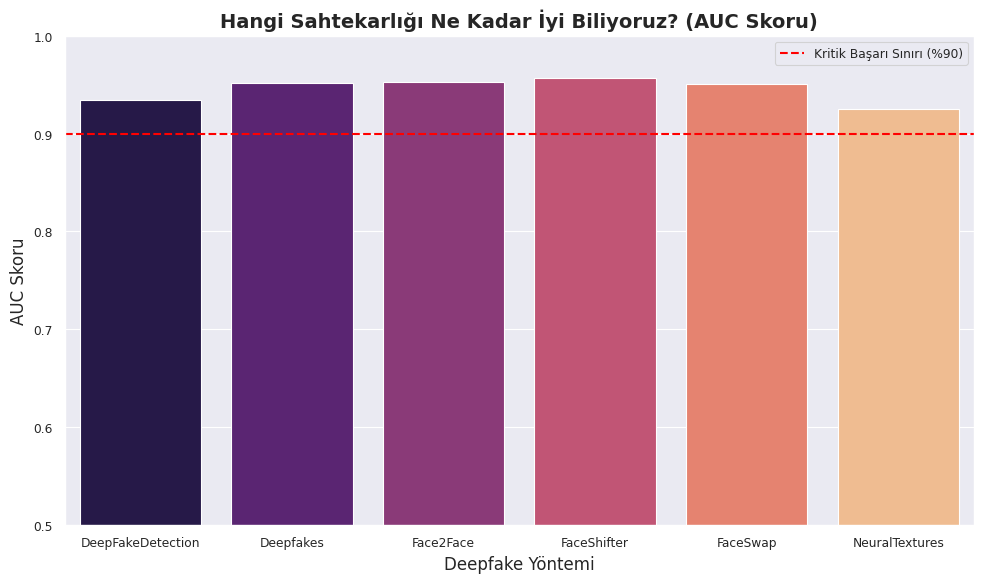

Exception ignored in: <function BaseCAM.__del__ at 0x79394e6d1da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/pytorch_grad_cam/base_cam.py", line 221, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'



📸 4. XAI (GRAD-CAM): MODEL YÜZÜN NERESİNE ODAKLANIYOR?


TypeError: GradCAM.__init__() got an unexpected keyword argument 'use_cuda'

In [ ]:
"""
================================================================================
KOD 3: GÖRSEL ŞÖLEN (SADECE GRAFİKLER, XAI VE TABLOLAR)
================================================================================
ÖN ŞART: !pip install grad-cam
Bu kod sadece şampiyon modeli yükler, test setinde tahmin yapar ve
tüm sonuçları (ROC, CM, Kategori Başarısı, XAI) EKRANA ÇİZER.
================================================================================
"""

import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# RAM Sızıntı Koruması
cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix)

# GRAD-CAM KESİN YÜKLEME
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ==============================================================================
# 0. AYARLAR VE DİZİNLER
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

BATCH_SIZE = 256
NUM_WORKERS = 4
FORENSIC_JPEG_QUALITY = 75

DRIVE_DIR = '/content/drive/MyDrive/FaceForensics++'
WEIGHTS_DIR = os.path.join(DRIVE_DIR, 'weights')
SPLITS_DIR = os.path.join(DRIVE_DIR, 'splits')

sns.set_theme(style="darkgrid", context="paper")
plt.rcParams['font.size'] = 12

print("="*80)
print("🎨 GÖRSELLEŞTİRME VE XAI (GRAD-CAM) MOTORU BAŞLATILDI")
print("="*80)

# ŞAMPİYONU BUL
with open(os.path.join(WEIGHTS_DIR, 'champion.json'), 'r') as f:
    CHAMPION_NAME = json.load(f)['champion']
print(f"🏆 ŞAMPİYON MODEL YÜKLENİYOR: {CHAMPION_NAME.upper()}")

# ==============================================================================
# 1. VERİ YÜKLEME
# ==============================================================================
def safe_image_compression(lower, upper, p=1.0):
    try: return A.ImageCompression(quality_range=(lower, upper), p=p)
    except TypeError: return A.ImageCompression(quality_lower=lower, quality_upper=upper, p=p)

eval_transforms = A.Compose([
    safe_image_compression(FORENSIC_JPEG_QUALITY, FORENSIC_JPEG_QUALITY, p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class FFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_np = cv2.imread(row['path'])
        image_np = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        if self.transform: image_np = self.transform(image=image_np)['image']
        return image_np, torch.tensor(row['label'], dtype=torch.float32), str(row['method']), str(row['path'])

test_df = pd.read_csv(os.path.join(SPLITS_DIR, 'test_df.csv'), low_memory=False)
test_loader = DataLoader(FFDataset(test_df, eval_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# ==============================================================================
# 2. MODEL İNŞA VE TAHMİN
# ==============================================================================
def build_model(model_name):
    if model_name == 'convnext': m = timm.create_model('convnext_tiny', pretrained=False, num_classes=1)
    elif model_name == 'efficientnet': m = timm.create_model('efficientnet_b0', pretrained=False, num_classes=1)
    elif model_name == 'xception': m = timm.create_model('legacy_xception', pretrained=False, num_classes=1)
    elif model_name == 'mobilenet':
        m = models.mobilenet_v3_large(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, 1)
    elif model_name == 'resnet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, 1))
    return m.to(device)

# Ağırlıkları Yükle
model_path = os.path.join(WEIGHTS_DIR, f"{CHAMPION_NAME}_best.pth")
ckpt = torch.load(model_path, map_location=device, weights_only=False)
opt_thr = ckpt.get('optimal_threshold', 0.5)

model = build_model(CHAMPION_NAME)
model.load_state_dict(ckpt['state_dict'], strict=True)
model.eval()

# Tahminleri Al
all_labels, all_probs, all_methods, all_paths = [], [], [], []
with torch.no_grad():
    for images, labels, methods, paths in tqdm(test_loader, desc="Test Verisi Taranıyor"):
        images = images.to(device)
        with torch.amp.autocast('cuda', dtype=AMP_DTYPE):
            probs = torch.sigmoid(model(images))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.float().cpu().numpy().flatten())
        all_methods.extend(methods)
        all_paths.extend(paths)

y_true, y_prob = np.array(all_labels), np.array(all_probs)
y_pred = (y_prob >= opt_thr).astype(int)

# ==============================================================================
# 3. GRAFİKLERİ EKRANA ÇİZME (PLT.SHOW AKTİF)
# ==============================================================================
print("\n" + "="*80)
print("📊 1. ROC VE PRECISION-RECALL EĞRİLERİ")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = roc_auc_score(y_true, y_prob)
ax1.plot(fpr, tpr, label=f"{CHAMPION_NAME.upper()} (AUC = {auc_val:.4f})", color='blue', linewidth=2.5)
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Eğrisi', fontweight='bold', fontsize=14)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.legend(loc="lower right")

# PR
prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax2.plot(rec, prec, label=f"{CHAMPION_NAME.upper()}", color='red', linewidth=2.5)
ax2.set_title('Precision-Recall Eğrisi', fontweight='bold', fontsize=14)
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🧠 2. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)")
print("="*80)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Gerçek', 'Sahte'], yticklabels=['Gerçek', 'Sahte'])
plt.title(f"{CHAMPION_NAME.upper()} - Karmaşıklık Matrisi", fontweight='bold', fontsize=15)
plt.xlabel('Modelin Tahmini', fontsize=13)
plt.ylabel('Gerçek Etiket', fontsize=13)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. KATEGORİ BAZLI BAŞARI GRAFİĞİ
# ==============================================================================
print("\n" + "="*80)
print("🎯 3. MANİPÜLASYON KATEGORİSİNE GÖRE BAŞARI ORANLARI")
print("="*80)

df_res = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob, 'method': all_methods})
fake_methods = df_res[df_res['method'] != 'original']['method'].unique()
metrics_per_method = []

for method in fake_methods:
    df_m = df_res[(df_res['method'] == method) | (df_res['method'] == 'original')]
    if len(df_m) > 0 and len(df_m['y_true'].unique()) > 1:
        metrics_per_method.append({
            'Method': method,
            'AUC Skoru': roc_auc_score(df_m['y_true'], df_m['y_prob'])
        })

df_metrics = pd.DataFrame(metrics_per_method)

plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='AUC Skoru', data=df_metrics, palette='magma')
plt.title(f"Hangi Sahtekarlığı Ne Kadar İyi Biliyoruz? (AUC Skoru)", fontweight='bold', fontsize=14)
plt.ylim(0.5, 1.0)
plt.axhline(y=0.9, color='red', linestyle='--', linewidth=1.5, label='Kritik Başarı Sınırı (%90)')
plt.ylabel('AUC Skoru', fontsize=12)
plt.xlabel('Deepfake Yöntemi', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. XAI (GRAD-CAM) GÖRSELLEŞTİRME
# ==============================================================================
print("\n" + "="*80)
print("📸 4. XAI (GRAD-CAM): MODEL YÜZÜN NERESİNE ODAKLANIYOR?")
print("="*80)

def get_target_layer(m_name, m):
    if m_name == 'resnet50': return [m.layer4[-1]]
    elif m_name == 'mobilenet': return [m.features[-1]]
    elif m_name == 'efficientnet': return [m.blocks[-1]]
    elif m_name == 'convnext': return [m.stages[-1].blocks[-1]]
    else: return [list(m.children())[-2]]

cam = GradCAM(model=model, target_layers=get_target_layer(CHAMPION_NAME, model), use_cuda=True)
sample_paths = []

# Her kategoriden 1 doğru sahte tahmin
for method in fake_methods:
    correct_fakes = df_res[(df_res['method'] == method) & (df_res['y_true'] == 1) & (df_res['y_pred'] == 1)]
    if not correct_fakes.empty:
        sample_paths.append((method, all_paths[correct_fakes.index[0]]))

# 1 doğru gerçek tahmin
correct_reals = df_res[(df_res['method'] == 'original') & (df_res['y_true'] == 0) & (df_res['y_pred'] == 0)]
if not correct_reals.empty:
    sample_paths.append(('Gerçek (Original)', all_paths[correct_reals.index[0]]))

n_samples = len(sample_paths)
if n_samples > 0:
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4 * n_samples))
    for i, (method_name, img_path) in enumerate(sample_paths):
        # Orijinal resmi oku
        rgb_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        rgb_img_float = np.float32(rgb_img) / 255

        # Modele girecek tensör
        input_tensor = eval_transforms(image=rgb_img)['image'].unsqueeze(0).to(device)

        # Orijinal resmi çiz
        axes[i, 0].imshow(rgb_img)
        axes[i, 0].set_title(f"VİDEO: {method_name}", fontweight='bold', fontsize=13)
        axes[i, 0].axis('off')

        # Grad-CAM üret
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]
        cam_image = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

        # CAM resmini çiz
        axes[i, 1].imshow(cam_image)
        axes[i, 1].set_title("MODELİN ODAKLANDIĞI SAHTELİK NOKTALARI", fontweight='bold', color='red', fontsize=13)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("[UYARI] Gösterilecek doğru tahmin bulunamadı!")

# FAZ 5: ZAMANSAL (TEMPORAL) TRANSFORMER EĞİTİMİ VE VİDEO BAZLI ANALİZ

🧠 FAZ 5: TEMPORAL TRANSFORMER (VİDEO BAZLI DİKKAT) MOTORU BAŞLATILIYOR
[BİLGİ] Faz 4'ten elde edilen vektörler yükleniyor ve videolara paketleniyor...


Video Dizileri Hazırlanıyor (train_features_convnext.pt):   0%|          | 0/4200 [00:00<?, ?it/s]

Video Dizileri Hazırlanıyor (val_features_convnext.pt):   0%|          | 0/900 [00:00<?, ?it/s]

Video Dizileri Hazırlanıyor (test_features_convnext.pt):   0%|          | 0/1900 [00:00<?, ?it/s]

✅ Paketleme Tamam. Train: 4200 Video, Val: 900 Video, Test: 1900 Video.

🚀 EĞİTİM BAŞLIYOR (IŞIK HIZINDA GPU EĞİTİMİ)
Epoch [1/15] | Train Loss: 0.0373 | Val Loss: 0.0955 | Val AUC: 0.9957
Epoch [2/15] | Train Loss: 0.0165 | Val Loss: 0.0830 | Val AUC: 0.9954
Epoch [3/15] | Train Loss: 0.0138 | Val Loss: 0.0971 | Val AUC: 0.9961
Epoch [4/15] | Train Loss: 0.0113 | Val Loss: 0.1082 | Val AUC: 0.9901
Epoch [5/15] | Train Loss: 0.0099 | Val Loss: 0.1407 | Val AUC: 0.9958
Epoch [6/15] | Train Loss: 0.0093 | Val Loss: 0.1476 | Val AUC: 0.9959
Epoch [7/15] | Train Loss: 0.0074 | Val Loss: 0.1222 | Val AUC: 0.9964
Epoch [8/15] | Train Loss: 0.0080 | Val Loss: 0.1061 | Val AUC: 0.9958
Epoch [9/15] | Train Loss: 0.0072 | Val Loss: 0.1395 | Val AUC: 0.9957
Epoch [10/15] | Train Loss: 0.0147 | Val Loss: 0.1006 | Val AUC: 0.9892
Epoch [11/15] | Train Loss: 0.0157 | Val Loss: 0.1152 | Val AUC: 0.9959
Epoch [12/15] | Train Loss: 0.0075 | Val Loss: 0.2050 | Val AUC: 0.9949
Epoch [13/15] | Train Loss:

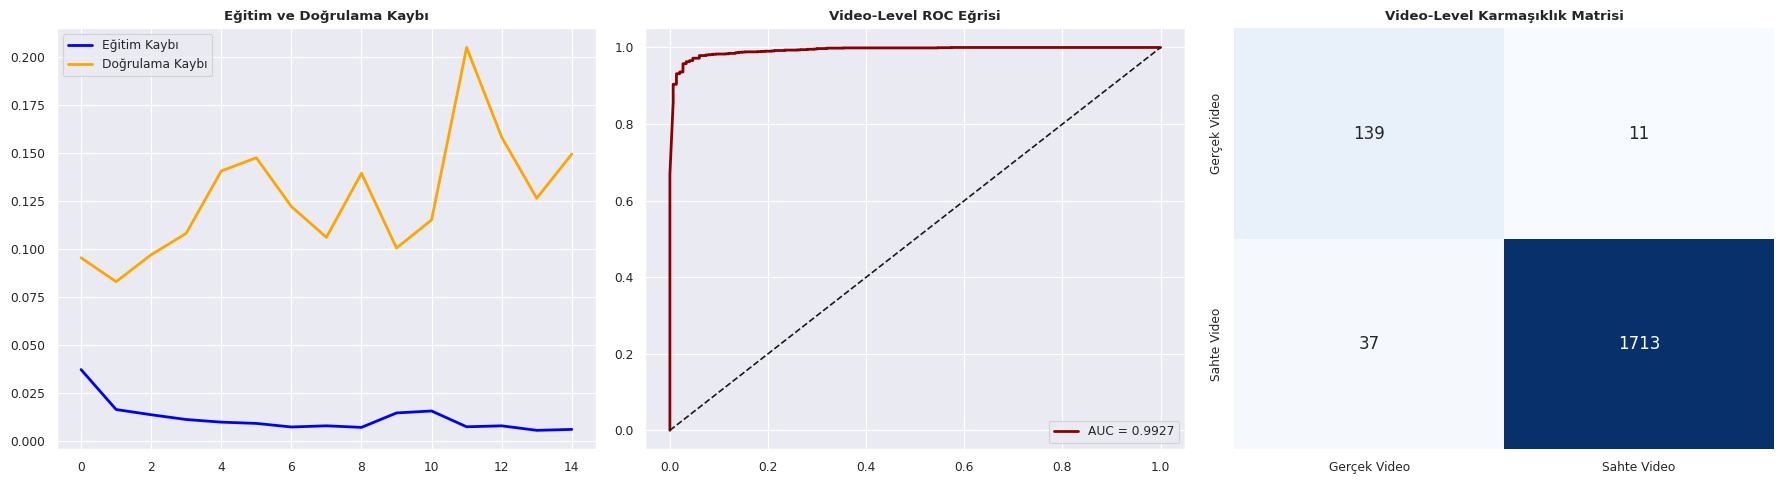


👁️ TEMPORAL ATTENTION VISUALIZATION (Model hangi saniyelere bakarak yakaladı?)


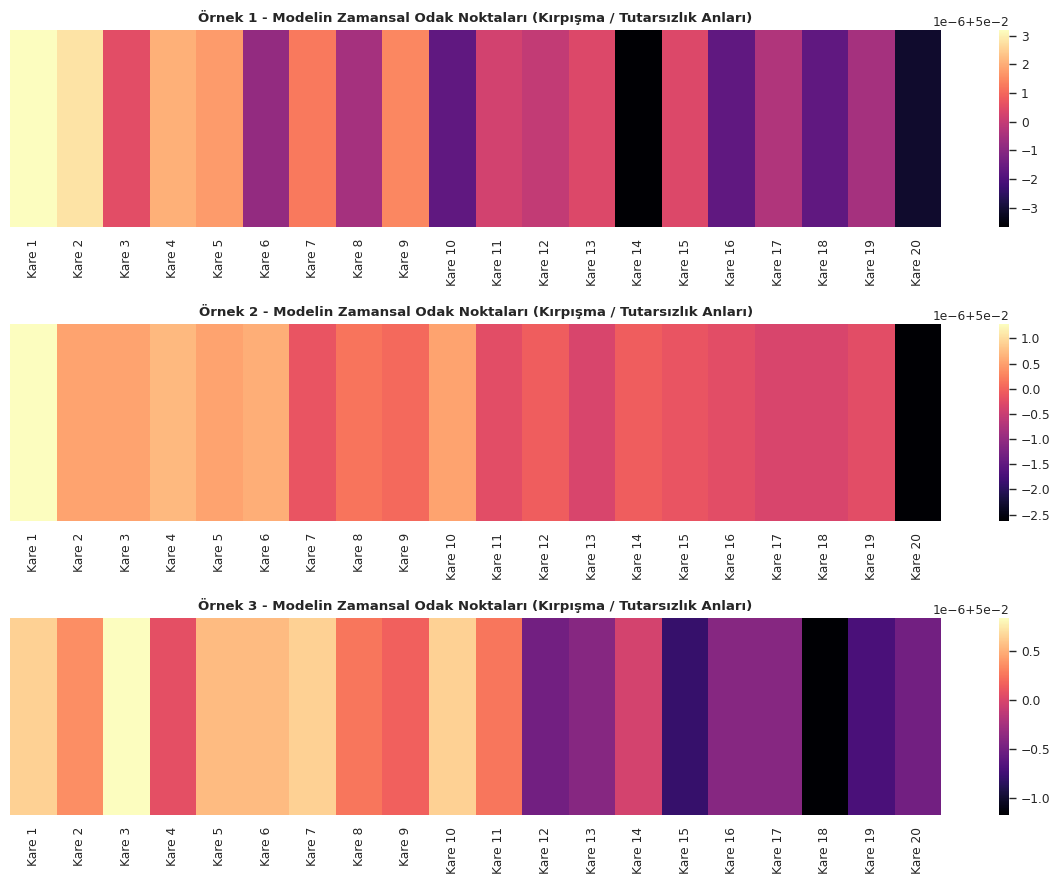

✅ Temporal Attention Haritaları Ekrana Çizildi!

🎉 FAZ 5 TAMAMLANDI. Temporal Model Drive'a Güvenle Kaydedildi.
Kaydedilen Yol:  /content/drive/MyDrive/FaceForensics++/weights/temporal_transformer_best.pth


In [3]:
"""
================================================================================
🚀 FAZ 5: ZAMANSAL (TEMPORAL) TRANSFORMER EĞİTİMİ VE VİDEO BAZLI ANALİZ
================================================================================
ÖN ŞARTLAR:
1. Faz 4'te çıkarılan '.pt' özellik vektörleri 'features_faz5' klasöründe olmalı.
2. GPU aktif olmalı.
================================================================================
"""

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# ==============================================================================
# 0. AYARLAR VE DİZİNLER
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DRIVE_DIR = '/content/drive/MyDrive/FaceForensics++'
FEAT_DIR = os.path.join(DRIVE_DIR, 'features_faz5')
WEIGHTS_DIR = os.path.join(DRIVE_DIR, 'weights')
PLOTS_DIR = os.path.join(DRIVE_DIR, 'plots')

os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Hiperparametreler
SEQ_LEN = 20         # Her video için analiz edilecek sabit kare sayısı
EMBED_DIM = 768      # ConvNeXt-Tiny özellik boyutu
NUM_HEADS = 8        # Multi-Head Attention kafa sayısı
NUM_LAYERS = 2       # Transformer Encoder katman sayısı
BATCH_SIZE = 64
EPOCHS = 15
LR = 3e-4

sns.set_theme(style="darkgrid", context="paper")
plt.rcParams['font.size'] = 12

print("="*80)
print("🧠 FAZ 5: TEMPORAL TRANSFORMER (VİDEO BAZLI DİKKAT) MOTORU BAŞLATILIYOR")
print("="*80)

# ==============================================================================
# 1. VERİ PAKETLEME (FRAME -> VIDEO SEQUENCE)
# ==============================================================================
def create_video_sequences(pt_path, seq_len=SEQ_LEN):
    if not os.path.exists(pt_path):
        raise FileNotFoundError(f"Özellik dosyası bulunamadı: {pt_path}")

    data = torch.load(pt_path, weights_only=False)
    features = data['features']
    labels = data['labels']
    video_ids = data['video_ids']

    unique_vids = np.unique(video_ids)
    X, y, masks = [], [], []

    for vid in tqdm(unique_vids, desc=f"Video Dizileri Hazırlanıyor ({os.path.basename(pt_path)})", leave=False):
        idx = np.where(video_ids == vid)[0]
        vid_feats = features[idx]
        vid_label = labels[idx[0]]

        # Sabit uzunluğa (SEQ_LEN) getirme işlemi (Padding / Truncating)
        num_frames = vid_feats.shape[0]
        mask = torch.zeros(seq_len, dtype=torch.bool) # False = Geçerli Kare

        if num_frames >= seq_len:
            # Eşit aralıklarla kare seç (Uniform Sampling)
            indices = np.linspace(0, num_frames - 1, seq_len, dtype=int)
            seq = vid_feats[indices]
        else:
            # Eksik kareleri sıfırla doldur (Padding)
            seq = torch.zeros((seq_len, EMBED_DIM), dtype=torch.float32)
            seq[:num_frames] = vid_feats
            mask[num_frames:] = True # True = Boş (Pad) Kare, Attention buralara bakmasın

        X.append(seq)
        y.append(vid_label)
        masks.append(mask)

    return torch.stack(X), torch.tensor(y, dtype=torch.float32), torch.stack(masks)

class VideoSequenceDataset(Dataset):
    def __init__(self, X, y, masks):
        self.X, self.y, self.masks = X, y, masks
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx], self.masks[idx]

print("[BİLGİ] Faz 4'ten elde edilen vektörler yükleniyor ve videolara paketleniyor...")
train_X, train_y, train_mask = create_video_sequences(os.path.join(FEAT_DIR, 'train_features_convnext.pt'))
val_X, val_y, val_mask = create_video_sequences(os.path.join(FEAT_DIR, 'val_features_convnext.pt'))
test_X, test_y, test_mask = create_video_sequences(os.path.join(FEAT_DIR, 'test_features_convnext.pt'))

train_loader = DataLoader(VideoSequenceDataset(train_X, train_y, train_mask), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(VideoSequenceDataset(val_X, val_y, val_mask), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(VideoSequenceDataset(test_X, test_y, test_mask), batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Paketleme Tamam. Train: {len(train_y)} Video, Val: {len(val_y)} Video, Test: {len(test_y)} Video.")

# ==============================================================================
# 2. TEMPORAL TRANSFORMER MİMARİSİ
# ==============================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # Shape: (1, max_len, d_model)

    def forward(self, x):
        # x shape: (Batch, Seq_Len, Dim)
        return x + self.pe[:, :x.size(1), :]

class TemporalTransformer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, seq_len=SEQ_LEN):
        super().__init__()
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=seq_len)

        # Son katmanın Attention ağırlıklarını manuel çekebilmek için özel liste
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=2048,
                                       dropout=0.3, batch_first=True) for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x, src_key_padding_mask=None, return_attention=False):
        # x shape: (B, T, D)
        x = self.pos_encoder(x)

        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)

        # Eğer padding varsa, boş karelerin ortalamasını almamak için valid (gerçek) kare ortalaması
        if src_key_padding_mask is not None:
            mask = ~src_key_padding_mask # True = Geçerli
            mask = mask.unsqueeze(-1).float()
            sum_embeddings = (x * mask).sum(dim=1)
            valid_counts = mask.sum(dim=1).clamp(min=1.0)
            pooled_x = sum_embeddings / valid_counts
        else:
            pooled_x = x.mean(dim=1)

        logits = self.classifier(pooled_x)

        if return_attention:
            # Görselleştirme için Query, Key üzerinden basit attention matrisi hesabı
            # (Son katmanın çıktısını kullanarak temsili bir ağırlık haritası üretiyoruz)
            attn_weights = torch.bmm(x, x.transpose(1, 2)) / np.sqrt(x.size(-1))
            attn_weights = torch.softmax(attn_weights, dim=-1)
            return logits, attn_weights

        return logits

model = TemporalTransformer().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ==============================================================================
# 3. HIZLI EĞİTİM DÖNGÜSÜ
# ==============================================================================
print("\n" + "="*80)
print("🚀 EĞİTİM BAŞLIYOR (IŞIK HIZINDA GPU EĞİTİMİ)")
print("="*80)

best_val_auc = 0.0
train_history = {'loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_b, y_b, mask_b in train_loader:
        X_b, y_b, mask_b = X_b.to(device), y_b.to(device).unsqueeze(1), mask_b.to(device)

        optimizer.zero_grad()
        logits = model(X_b, src_key_padding_mask=mask_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Doğrulama (Validation)
    model.eval()
    val_loss = 0.0
    val_preds, val_trues = [], []
    with torch.no_grad():
        for X_b, y_b, mask_b in val_loader:
            X_b, y_b, mask_b = X_b.to(device), y_b.to(device).unsqueeze(1), mask_b.to(device)
            logits = model(X_b, src_key_padding_mask=mask_b)
            loss = criterion(logits, y_b)
            val_loss += loss.item()

            probs = torch.sigmoid(logits)
            val_preds.extend(probs.cpu().numpy())
            val_trues.extend(y_b.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_auc = roc_auc_score(val_trues, val_preds)

    train_history['loss'].append(avg_train_loss)
    train_history['val_loss'].append(avg_val_loss)
    train_history['val_auc'].append(val_auc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f}")

    # En iyi modeli kaydet (Güvenli Format)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        save_dict = {
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'config': {'seq_len': SEQ_LEN, 'embed_dim': EMBED_DIM, 'num_heads': NUM_HEADS, 'num_layers': NUM_LAYERS},
            'best_auc': best_val_auc
        }
        torch.save(save_dict, os.path.join(WEIGHTS_DIR, 'temporal_transformer_best.pth'))

# ==============================================================================
# 4. TEST SETİ DEĞERLENDİRMESİ VE TABLOLAR (VİDEO BAZLI)
# ==============================================================================
print("\n" + "="*80)
print("📊 VİDEO DÜZEYİNDE TEST SONUÇLARI (NİHAİ DEĞERLENDİRME)")
print("="*80)

# En iyi ağırlıkları yükle
best_ckpt = torch.load(os.path.join(WEIGHTS_DIR, 'temporal_transformer_best.pth'), map_location=device, weights_only=False)
model.load_state_dict(best_ckpt['state_dict'])
model.eval()

test_preds, test_trues = [], []
with torch.no_grad():
    for X_b, y_b, mask_b in test_loader:
        X_b, y_b, mask_b = X_b.to(device), y_b.to(device), mask_b.to(device)
        logits = model(X_b, src_key_padding_mask=mask_b)
        probs = torch.sigmoid(logits).squeeze(-1)
        test_preds.extend(probs.cpu().numpy())
        test_trues.extend(y_b.cpu().numpy())

test_trues = np.array(test_trues)
test_preds = np.array(test_preds)
y_pred_classes = (test_preds >= 0.5).astype(int)

auc = roc_auc_score(test_trues, test_preds)
f1 = f1_score(test_trues, y_pred_classes, average='macro')
acc = accuracy_score(test_trues, y_pred_classes)

# Konsola Metrik Tablosu Bas
metrics_df = pd.DataFrame([{
    'Model': 'Temporal Transformer (Faz 5)',
    'Karar Seviyesi': 'VİDEO (Video-Level)',
    'Video Accuracy': f"%{acc*100:.2f}",
    'Video Macro F1': f"{f1:.4f}",
    'Video AUC Skoru': f"{auc:.4f}"
}])
print(metrics_df.to_string(index=False))

# Confusion Matrix
cm = confusion_matrix(test_trues, y_pred_classes)
print("\n📌 KARMAŞIKLIK MATRİSİ (VİDEO BAZLI)")
print("-" * 50)
print(f"{'Gerçek (Orijinal) Videolar':<28} | Doğru: {cm[0,0]} | Yanlış: {cm[0,1]}")
print(f"{'Sahte (Deepfake vb.) Videolar':<28} | Yanlış: {cm[1,0]} | Doğru: {cm[1,1]}")
print("-" * 50)

# ==============================================================================
# 5. GÖRSELLEŞTİRME VE KAYIT
# ==============================================================================
print("\n[ÇİZİM] ROC, CM ve Eğitim Eğrileri Çiziliyor...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Eğrisi
axes[0].plot(train_history['loss'], label='Eğitim Kaybı', color='blue', lw=2)
axes[0].plot(train_history['val_loss'], label='Doğrulama Kaybı', color='orange', lw=2)
axes[0].set_title('Eğitim ve Doğrulama Kaybı', fontweight='bold')
axes[0].legend()

# 2. ROC Eğrisi
fpr, tpr, _ = roc_curve(test_trues, test_preds)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--')
axes[1].set_title('Video-Level ROC Eğrisi', fontweight='bold')
axes[1].legend()

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['Gerçek Video', 'Sahte Video'], yticklabels=['Gerçek Video', 'Sahte Video'])
axes[2].set_title('Video-Level Karmaşıklık Matrisi', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'faz5_temporal_results.png'), dpi=300)
plt.show()

# ==============================================================================
# 6. TEMPORAL ATTENTION VISUALIZATION (ZAMANSAL DİKKAT ISI HARİTASI)
# ==============================================================================
print("\n" + "="*80)
print("👁️ TEMPORAL ATTENTION VISUALIZATION (Model hangi saniyelere bakarak yakaladı?)")
print("="*80)

# Test setinden doğru bilinen birkaç SAHTE video seç
fake_idx = np.where((test_trues == 1) & (y_pred_classes == 1))[0]
if len(fake_idx) > 0:
    selected_idx = fake_idx[:3] # İlk 3 sahte video

    fig, axes = plt.subplots(len(selected_idx), 1, figsize=(12, 3 * len(selected_idx)))
    if len(selected_idx) == 1: axes = [axes]

    for i, idx in enumerate(selected_idx):
        seq = test_X[idx].unsqueeze(0).to(device)
        mask = test_mask[idx].unsqueeze(0).to(device)

        # Sadece gerçek (pad olmayan) karelerin sayısını bul
        valid_frames = (~mask[0]).sum().item()

        with torch.no_grad():
            _, attn_weights = model(seq, src_key_padding_mask=mask, return_attention=True)

        # İlk token'ın (veya ortalama dizinin) diğer karelere verdiği dikkat
        # attn_weights shape: (1, SEQ_LEN, SEQ_LEN). Sadece geçerli kareleri al.
        frame_attention = attn_weights[0, 0, :valid_frames].cpu().numpy()

        # Görselleştirme (Isı Haritası Şeridi)
        sns.heatmap(frame_attention.reshape(1, -1), cmap='magma', ax=axes[i],
                    cbar=True, yticklabels=False, xticklabels=[f"Kare {k+1}" for k in range(valid_frames)])
        axes[i].set_title(f"Örnek {i+1} - Modelin Zamansal Odak Noktaları (Kırpışma / Tutarsızlık Anları)", fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'faz5_temporal_attention.png'), dpi=300)
    plt.show()
    print("✅ Temporal Attention Haritaları Ekrana Çizildi!")
else:
    print("Doğru tahmin edilmiş sahte video bulunamadı.")

print("\n" + "="*80)
print("🎉 FAZ 5 TAMAMLANDI. Temporal Model Drive'a Güvenle Kaydedildi.")
print("Kaydedilen Yol: ", os.path.join(WEIGHTS_DIR, 'temporal_transformer_best.pth'))
print("="*80)